In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

In [2]:
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
print(f"Using device: {torch.cuda.get_device_name(0)}")
torch.cuda.empty_cache()

Using device: NVIDIA H100 PCIe


In [3]:
def tube_loss(y, mu1, mu2, t=0.95, r=0.5):
    lower = torch.min(mu1, mu2)
    upper = torch.max(mu1, mu2)
    loss = torch.zeros_like(y)

    loss[y > upper] = t * (y[y > upper] - upper[y > upper])
    loss[y < lower] = t * (lower[y < lower] - y[y < lower])

    mid = r * upper + (1 - r) * lower
    mask = (y >= lower) & (y <= upper)
    loss[mask & (y >= mid)] = (1 - t) * (upper[mask & (y >= mid)] - y[mask & (y >= mid)])
    loss[mask & (y < mid)]  = (1 - t) * (y[mask & (y < mid)] - lower[mask & (y < mid)])

    return loss.mean()

In [4]:
class CategoryHeadModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(1536, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, 2)
        )

    def forward(self, fused):
        return self.head(fused)

class ScaledRFPDataset(Dataset):
    def __init__(self, pt_file_path, mu, sigma):
        data = torch.load(pt_file_path, weights_only=False)
        self.embeddings = data['embeddings']
        self.indices = data['dataframe_indices']
        raw_log_prices = data['log_prices']
        self.targets = (raw_log_prices - mu) / sigma
        
    def __len__(self):
        return len(self.embeddings)
    
    def __getitem__(self, idx):
        x = self.embeddings[idx]
        y = torch.tensor(self.targets[idx], dtype=torch.float32)
        return x, y

In [5]:
def train_category_models(split_dir="split_embeddings", save_dir="saved_models", epochs=5, t_val=0.95, r_val=0.5):
    os.makedirs(save_dir, exist_ok=True)
    # device = "cuda" if torch.cuda.is_available() else "cpu"
    device="cpu"
    print(f"Using device: {device}")
    
    train_files = [f for f in os.listdir(os.path.join(split_dir, 'train')) if f.endswith('.pt')]
    
    for file in train_files:
        cat_name = file.replace('combined_', '').replace('.pt', '')
        train_file_path = os.path.join(split_dir, 'train', file)
            
        print(f"\n{'-'*50}")
        print(f"TRAINING CATEGORY: {cat_name.upper()}")
        
        raw_train_data = torch.load(train_file_path, weights_only=False)
        cat_mu = raw_train_data['log_prices'].mean().item()
        cat_sigma = raw_train_data['log_prices'].std().item()
        
        train_dataset = ScaledRFPDataset(train_file_path, cat_mu, cat_sigma)
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
        
        model = CategoryHeadModel().to(device)
        optimizer = AdamW(model.parameters(), lr=1e-3)
        
        for epoch in range(epochs):
            model.train()
            total_loss = 0
            
            for imgs_txts_fused, y in train_loader:
                imgs_txts_fused, y = imgs_txts_fused.to(device), y.to(device)
                
                optimizer.zero_grad()
                out = model(imgs_txts_fused)
                loss = tube_loss(y, out[:,0], out[:,1], t=t_val, r=r_val)
                
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
                
            print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f}")
            
        model_path = os.path.join(save_dir, f"model_{cat_name}.pth")
        torch.save({
            'model_state_dict': model.state_dict(),
            'mu': cat_mu,
            'sigma': cat_sigma
        }, model_path)
        print(f"-> Model & scalers saved to {model_path}")

In [6]:
def evaluate_category_models(split_dir="split_embeddings", load_dir="saved_models"):
    # device = "cuda" if torch.cuda.is_available() else "cpu"
    device="cpu"
    print(f"Evaluating on device: {device}")
    
    saved_models = [f for f in os.listdir(load_dir) if f.endswith('.pth')]
    
    for model_file in saved_models:
        cat_name = model_file.replace('model_', '').replace('.pth', '')
        test_file_path = os.path.join(split_dir, 'test', f"combined_{cat_name}.pt")
        model_path = os.path.join(load_dir, model_file)
        
        if not os.path.exists(test_file_path):
            print(f"Test data missing for {cat_name}, skipping...")
            continue
            
        print(f"\n{'-'*50}")
        print(f"EVALUATING CATEGORY: {cat_name.upper()}")
        
        checkpoint = torch.load(model_path, map_location=device, weights_only=False)
        cat_mu = checkpoint['mu']
        cat_sigma = checkpoint['sigma']
        
        model = CategoryHeadModel().to(device)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.eval()
        
        test_dataset = ScaledRFPDataset(test_file_path, cat_mu, cat_sigma)
        test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
        
        lowers, uppers, ys = [], [], []

        with torch.no_grad():
            for fused, y_n in test_loader:
                fused = fused.to(device)
                out = model(fused)
                # Inverse Transform
                l = torch.min(out[:,0], out[:,1]) * cat_sigma + cat_mu
                u = torch.max(out[:,0], out[:,1]) * cat_sigma + cat_mu
                y_true = y_n * cat_sigma + cat_mu

                l = torch.exp(l)
                u = torch.exp(u)
                y_true = torch.exp(y_true)

                lowers.append(l.cpu())
                uppers.append(u.cpu())
                ys.append(y_true.cpu())
                
        lower_preds = torch.cat(lowers)
        upper_preds = torch.cat(uppers)
        y_trues = torch.cat(ys)

        cat_picp = ((y_trues >= lower_preds) & (y_trues <= upper_preds)).float().mean()
        cat_mpiw = (upper_preds - lower_preds).mean()
        mid_preds = (lower_preds + upper_preds) / 2.0

        cat_mse = torch.mean((y_trues - mid_preds) ** 2)
        cat_rmse = torch.sqrt(cat_mse)

        print(f"[{cat_name.upper()}] PICP: {cat_picp.item():.4f}")
        print(f"[{cat_name.upper()}] MPIW: {cat_mpiw.item():.2f}")
        print(f"[{cat_name.upper()}] RMSE (Midpoint): {cat_rmse.item():.2f}")

In [119]:
train_category_models(epochs=5, t_val=0.98, r_val=0.5)

Using device: cpu

--------------------------------------------------
TRAINING CATEGORY: BIKES
Epoch 1/5 | Loss: 0.1733
Epoch 2/5 | Loss: 0.0622
Epoch 3/5 | Loss: 0.0443
Epoch 4/5 | Loss: 0.0440
Epoch 5/5 | Loss: 0.0334
-> Model & scalers saved to saved_models/model_bikes.pth

--------------------------------------------------
TRAINING CATEGORY: BOOKS
Epoch 1/5 | Loss: 0.1643
Epoch 2/5 | Loss: 0.0412
Epoch 3/5 | Loss: 0.0379
Epoch 4/5 | Loss: 0.0402
Epoch 5/5 | Loss: 0.0471
-> Model & scalers saved to saved_models/model_books.pth

--------------------------------------------------
TRAINING CATEGORY: CARS
Epoch 1/5 | Loss: 0.1822
Epoch 2/5 | Loss: 0.0435
Epoch 3/5 | Loss: 0.0499
Epoch 4/5 | Loss: 0.0431
Epoch 5/5 | Loss: 0.0356
-> Model & scalers saved to saved_models/model_cars.pth

--------------------------------------------------
TRAINING CATEGORY: CYCLE
Epoch 1/5 | Loss: 0.1949
Epoch 2/5 | Loss: 0.0578
Epoch 3/5 | Loss: 0.0835
Epoch 4/5 | Loss: 0.0404
Epoch 5/5 | Loss: 0.0445
-> Mo

In [120]:
evaluate_category_models()

Evaluating on device: cpu

--------------------------------------------------
EVALUATING CATEGORY: BIKES
[BIKES] PICP: 1.0000
[BIKES] MPIW: 773423.25
[BIKES] RMSE (Midpoint): 293038.09

--------------------------------------------------
EVALUATING CATEGORY: BOOKS
[BOOKS] PICP: 1.0000
[BOOKS] MPIW: 1328243.25
[BOOKS] RMSE (Midpoint): 736107.75

--------------------------------------------------
EVALUATING CATEGORY: CARS
[CARS] PICP: 0.8065
[CARS] MPIW: 37212916.00
[CARS] RMSE (Midpoint): 18445330.00

--------------------------------------------------
EVALUATING CATEGORY: CYCLE
[CYCLE] PICP: 1.0000
[CYCLE] MPIW: 169214.55
[CYCLE] RMSE (Midpoint): 76120.25

--------------------------------------------------
EVALUATING CATEGORY: FLAT
[FLAT] PICP: 1.0000
[FLAT] MPIW: 46399620.00
[FLAT] RMSE (Midpoint): 17478480.00

--------------------------------------------------
EVALUATING CATEGORY: FRIDGES
[FRIDGES] PICP: 0.9867
[FRIDGES] MPIW: 61671.19
[FRIDGES] RMSE (Midpoint): 28259.83

-------------

In [121]:
torch.cuda.empty_cache()

In [7]:
def set_seed(seed):
    """Sets the seed for completely reproducible, yet distinct, model runs."""
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

def train_deep_ensembles(split_dir="split_embeddings", save_dir="ensemble_models", n_models=3, epochs=5, t_val=0.95, r_val=0.5):
    os.makedirs(save_dir, exist_ok=True)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    device="cpu"
    train_files = [f for f in os.listdir(os.path.join(split_dir, 'train')) if f.endswith('.pt')]
    
    for file in train_files:
        cat_name = file.replace('combined_', '').replace('.pt', '')
        train_file_path = os.path.join(split_dir, 'train', file)
        
        print(f"\n{'-'*50}")
        print(f"TRAINING ENSEMBLE ({n_models} Models) FOR: {cat_name.upper()}")
        
        raw_train_data = torch.load(train_file_path, weights_only=False)
        cat_mu = raw_train_data['log_prices'].mean().item()
        cat_sigma = raw_train_data['log_prices'].std().item()
        
        train_dataset = ScaledRFPDataset(train_file_path, cat_mu, cat_sigma)
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
        
        for ensemble_idx in range(n_models):
            current_seed = 42 + ensemble_idx
            set_seed(current_seed)
            
            print(f"\n Training Model {ensemble_idx + 1}/{n_models} (Seed {current_seed})...")
            
            model = CategoryHeadModel().to(device)
            optimizer = AdamW(model.parameters(), lr=1e-3)
            
            for epoch in range(epochs):
                model.train()
                total_loss = 0
                for imgs_txts_fused, y in train_loader:
                    imgs_txts_fused, y = imgs_txts_fused.to(device), y.to(device)
                    optimizer.zero_grad()
                    out = model(imgs_txts_fused)
                    loss = tube_loss(y, out[:,0], out[:,1], t=t_val, r=r_val)
                    loss.backward()
                    optimizer.step()
                    total_loss += loss.item()
                    
                if (epoch + 1) == epochs or (epoch + 1) % 5 == 0:
                    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f}")
            
            model_path = os.path.join(save_dir, f"model_{cat_name}_ens{ensemble_idx}.pth")
            torch.save({
                'model_state_dict': model.state_dict(),
                'mu': cat_mu,
                'sigma': cat_sigma
            }, model_path)
            print(f"-> Saved Ensemble Member {ensemble_idx + 1}")

In [123]:
def evaluate_deep_ensembles(split_dir="split_embeddings", load_dir="ensemble_models", n_models=3):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    device="cpu"
    test_files = [f for f in os.listdir(os.path.join(split_dir, 'test')) if f.endswith('.pt')]
    
    for file in test_files:
        cat_name = file.replace('combined_', '').replace('.pt', '')
        test_file_path = os.path.join(split_dir, 'test', file)
        
        print(f"\n{'-'*50}")
        print(f"EVALUATING ENSEMBLE FOR: {cat_name.upper()}")
        
        first_model_path = os.path.join(load_dir, f"model_{cat_name}_ens0.pth")
        if not os.path.exists(first_model_path):
            print("Ensemble not found, skipping...")
            continue
            
        checkpoint = torch.load(first_model_path, map_location=device, weights_only=False)
        cat_mu, cat_sigma = checkpoint['mu'], checkpoint['sigma']
        
        # Load all N models into a list
        ensemble = []
        for i in range(n_models):
            model = CategoryHeadModel().to(device)
            ckpt = torch.load(os.path.join(load_dir, f"model_{cat_name}_ens{i}.pth"), map_location=device, weights_only=False)
            model.load_state_dict(ckpt['model_state_dict'])
            model.eval()
            ensemble.append(model)
            
        test_dataset = ScaledRFPDataset(test_file_path, cat_mu, cat_sigma)
        test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
        
        lowers_ens, uppers_ens, ys = [], [], []

        with torch.no_grad():
            for fused, y_n in test_loader:
                fused = fused.to(device)
                
                batch_lowers = []
                batch_uppers = []
                
                for model in ensemble:
                    out = model(fused)
                    l_scaled = torch.min(out[:,0], out[:,1])
                    u_scaled = torch.max(out[:,0], out[:,1])
                    
                    batch_lowers.append(l_scaled)
                    batch_uppers.append(u_scaled)
                
                batch_lowers = torch.stack(batch_lowers)
                batch_uppers = torch.stack(batch_uppers)
                
                median_l, _ = torch.median(batch_lowers, dim=0)
                median_u, _ = torch.median(batch_uppers, dim=0)

                l_real = torch.exp(median_l * cat_sigma + cat_mu)
                u_real = torch.exp(median_u * cat_sigma + cat_mu)
                y_true = torch.exp(y_n * cat_sigma + cat_mu)

                lowers_ens.append(l_real.cpu())
                uppers_ens.append(u_real.cpu())
                ys.append(y_true.cpu())
                
        lower_preds = torch.cat(lowers_ens)
        upper_preds = torch.cat(uppers_ens)
        y_trues = torch.cat(ys)

        cat_picp = ((y_trues >= lower_preds) & (y_trues <= upper_preds)).float().mean()
        cat_mpiw = (upper_preds - lower_preds).mean()
        mid_preds = (lower_preds + upper_preds) / 2.0
        cat_rmse = torch.sqrt(torch.mean((y_trues - mid_preds) ** 2))

        print(f"[{cat_name.upper()}] ENSEMBLE PICP: {cat_picp.item():.4f}")
        print(f"[{cat_name.upper()}] ENSEMBLE MPIW: {cat_mpiw.item():.2f}")
        print(f"[{cat_name.upper()}] ENSEMBLE RMSE: {cat_rmse.item():.2f}")

In [124]:
print("Starting Deep Ensemble Training Phase...")
train_deep_ensembles(
    split_dir="split_embeddings", 
    save_dir="ensemble_models", 
    n_models=5,
    epochs=5,
    t_val=0.98, 
    r_val=0.5
)
print("All ensemble models successfully trained and saved!")

Starting Deep Ensemble Training Phase...

--------------------------------------------------
TRAINING ENSEMBLE (5 Models) FOR: BIKES

 Training Model 1/5 (Seed 42)...
Epoch 5/5 | Loss: 0.0433
-> Saved Ensemble Member 1

 Training Model 2/5 (Seed 43)...
Epoch 5/5 | Loss: 0.0403
-> Saved Ensemble Member 2

 Training Model 3/5 (Seed 44)...
Epoch 5/5 | Loss: 0.0394
-> Saved Ensemble Member 3

 Training Model 4/5 (Seed 45)...
Epoch 5/5 | Loss: 0.0704
-> Saved Ensemble Member 4

 Training Model 5/5 (Seed 46)...
Epoch 5/5 | Loss: 0.0317
-> Saved Ensemble Member 5

--------------------------------------------------
TRAINING ENSEMBLE (5 Models) FOR: BOOKS

 Training Model 1/5 (Seed 42)...
Epoch 5/5 | Loss: 0.0342
-> Saved Ensemble Member 1

 Training Model 2/5 (Seed 43)...
Epoch 5/5 | Loss: 0.0316
-> Saved Ensemble Member 2

 Training Model 3/5 (Seed 44)...
Epoch 5/5 | Loss: 0.0322
-> Saved Ensemble Member 3

 Training Model 4/5 (Seed 45)...
Epoch 5/5 | Loss: 0.0424
-> Saved Ensemble Member 4



In [125]:
print("Starting Deep Ensemble Evaluation Phase...")
evaluate_deep_ensembles(
    split_dir="split_embeddings", 
    load_dir="ensemble_models", 
    n_models=5        #Same as the number of models you trained
)

Starting Deep Ensemble Evaluation Phase...

--------------------------------------------------
EVALUATING ENSEMBLE FOR: BIKES
[BIKES] ENSEMBLE PICP: 1.0000
[BIKES] ENSEMBLE MPIW: 383464.91
[BIKES] ENSEMBLE RMSE: 117980.08

--------------------------------------------------
EVALUATING ENSEMBLE FOR: BOOKS
[BOOKS] ENSEMBLE PICP: 1.0000
[BOOKS] ENSEMBLE MPIW: 15200.75
[BOOKS] ENSEMBLE RMSE: 6330.63

--------------------------------------------------
EVALUATING ENSEMBLE FOR: CARS
[CARS] ENSEMBLE PICP: 0.9677
[CARS] ENSEMBLE MPIW: 27079444.00
[CARS] ENSEMBLE RMSE: 13065081.00

--------------------------------------------------
EVALUATING ENSEMBLE FOR: CYCLE
[CYCLE] ENSEMBLE PICP: 0.9655
[CYCLE] ENSEMBLE MPIW: 248066.97
[CYCLE] ENSEMBLE RMSE: 117081.80

--------------------------------------------------
EVALUATING ENSEMBLE FOR: FLAT
[FLAT] ENSEMBLE PICP: 1.0000
[FLAT] ENSEMBLE MPIW: 43658948.00
[FLAT] ENSEMBLE RMSE: 15648383.00

--------------------------------------------------
EVALUATING EN

Exp-3

In [97]:
!pip install lightgbm

In [8]:
import numpy as np
import lightgbm as lgb

In [9]:
class ResidualCategoryHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Linear(1536, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.3)
        )
        self.layer2 = nn.Sequential(
            nn.Linear(512, 512), # Keeping size same for skip connection
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.2)
        )
        self.output_layer = nn.Sequential(
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        # Pass through first layer
        out1 = self.layer1(x)
        # Pass through second layer AND add the out1 residual
        out2 = self.layer2(out1) + out1 
        # Final prediction
        return self.output_layer(out2)

In [10]:
class Category_Head_Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(1536, 512), nn.LayerNorm(512), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(512, 256), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(256, 2)
        )
    def forward(self, x): return self.head(x)


class ScaledRFPDataset(Dataset):
    def __init__(self, pt_file_path, mu, sigma):
        data = torch.load(pt_file_path, weights_only=False)
        self.embeddings = data['embeddings']
        raw_log_prices = data['log_prices']
        self.targets = (raw_log_prices - mu) / sigma
        
    def __len__(self): return len(self.embeddings)
    def __getitem__(self, idx):
        return self.embeddings[idx], torch.tensor(self.targets[idx], dtype=torch.float32)

In [12]:
def train_heterogeneous_ensemble(split_dir="split_embeddings", save_dir="het_ensemble_models", epochs=5, t_val=0.95, r_val=0.5):
    os.makedirs(save_dir, exist_ok=True)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    device="cpu"
    train_files = [f for f in os.listdir(os.path.join(split_dir, 'train')) if f.endswith('.pt')]
    
    for file in train_files:
        cat_name = file.replace('combined_', '').replace('.pt', '')
        train_file_path = os.path.join(split_dir, 'train', file)
        
        print(f"\n{'-'*60}")
        print(f"TRAINING HETEROGENEOUS ENSEMBLE FOR: {cat_name.upper()}")
        
        # 1. Load Data & Scalers
        raw_train_data = torch.load(train_file_path, weights_only=False)
        cat_mu = raw_train_data['log_prices'].mean().item()
        cat_sigma = raw_train_data['log_prices'].std().item()
        
        train_dataset = ScaledRFPDataset(train_file_path, cat_mu, cat_sigma)
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
        
        # Save Scalers
        torch.save({'mu': cat_mu, 'sigma': cat_sigma}, os.path.join(save_dir, f"scalers_{cat_name}.pt"))

        print("-> Training Model 1: Base MLP...")
        model_base = Category_Head_Model().to(device)
        opt_base = AdamW(model_base.parameters(), lr=1e-3)
        for _ in range(epochs):
            model_base.train()
            for x, y in train_loader:
                x, y = x.to(device), y.to(device)
                opt_base.zero_grad()
                out = model_base(x)
                loss = tube_loss(y, out[:,0], out[:,1], t=t_val, r=r_val)
                loss.backward()
                opt_base.step()
        torch.save(model_base.state_dict(), os.path.join(save_dir, f"model_base_{cat_name}.pth"))

        print("-> Training Model 2: Residual MLP...")
        model_res = ResidualCategoryHead().to(device)
        opt_res = AdamW(model_res.parameters(), lr=1e-3)
        for _ in range(epochs):
            model_res.train()
            for x, y in train_loader:
                x, y = x.to(device), y.to(device)
                opt_res.zero_grad()
                out = model_res(x)
                loss = tube_loss(y, out[:,0], out[:,1], t=t_val, r=r_val)
                loss.backward()
                opt_res.step()
        torch.save(model_res.state_dict(), os.path.join(save_dir, f"model_res_{cat_name}.pth"))

        print("-> Training Model 3: LightGBM Quantile Trees...")
        X_np = raw_train_data['embeddings'].numpy()
        y_np = train_dataset.targets.numpy()

        lgb_lower = lgb.LGBMRegressor(objective='quantile', alpha=1-t_val, n_estimators=100, random_state=42)
        lgb_upper = lgb.LGBMRegressor(objective='quantile', alpha=t_val, n_estimators=100, random_state=42)
        
        lgb_lower.fit(X_np, y_np)
        lgb_upper.fit(X_np, y_np)
        
        lgb_lower.booster_.save_model(os.path.join(save_dir, f"lgbm_lower_{cat_name}.txt"))
        lgb_upper.booster_.save_model(os.path.join(save_dir, f"lgbm_upper_{cat_name}.txt"))


In [13]:
import warnings
warnings.filterwarnings('ignore')

In [100]:
train_heterogeneous_ensemble()


------------------------------------------------------------
TRAINING HETEROGENEOUS ENSEMBLE FOR: BIKES
-> Training Model 1: Base MLP...
-> Training Model 2: Residual MLP...
-> Training Model 3: LightGBM Quantile Trees...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015638 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 99639
[LightGBM] [Info] Number of data points in the train set: 202, number of used features: 1536
[LightGBM] [Info] Start training from score -1.184663
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [101]:
def evaluate_heterogeneous_ensemble(split_dir="split_embeddings", load_dir="het_ensemble_models"):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    device="cpu"
    test_files = [f for f in os.listdir(os.path.join(split_dir, 'test')) if f.endswith('.pt')]
    
    for file in test_files:
        cat_name = file.replace('combined_', '').replace('.pt', '')
        test_file_path = os.path.join(split_dir, 'test', file)
        
        if not os.path.exists(os.path.join(load_dir, f"scalers_{cat_name}.pt")):
            continue
            
        print(f"\n{'-'*60}")
        print(f"EVALUATING HETEROGENEOUS ENSEMBLE FOR: {cat_name.upper()}")
        
        scalers = torch.load(os.path.join(load_dir, f"scalers_{cat_name}.pt"), weights_only=False)
        cat_mu, cat_sigma = scalers['mu'], scalers['sigma']
        
        model_base = Category_Head_Model().to(device)
        model_base.load_state_dict(torch.load(os.path.join(load_dir, f"model_base_{cat_name}.pth"), map_location=device, weights_only=True))
        model_base.eval()

        model_res = ResidualCategoryHead().to(device)
        model_res.load_state_dict(torch.load(os.path.join(load_dir, f"model_res_{cat_name}.pth"), map_location=device, weights_only=True))
        model_res.eval()

        # Load LightGBM Models
        lgb_lower = lgb.Booster(model_file=os.path.join(load_dir, f"lgbm_lower_{cat_name}.txt"))
        lgb_upper = lgb.Booster(model_file=os.path.join(load_dir, f"lgbm_upper_{cat_name}.txt"))

        test_dataset = ScaledRFPDataset(test_file_path, cat_mu, cat_sigma)
        test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
        
        lowers_ens, uppers_ens, ys = [], [], []

        with torch.no_grad():
            for x_batch, y_batch in test_loader:
                x_gpu = x_batch.to(device)
                
                # 1. Base MLP Predictions
                out_base = model_base(x_gpu)
                l_base = torch.min(out_base[:,0], out_base[:,1]).cpu()
                u_base = torch.max(out_base[:,0], out_base[:,1]).cpu()

                # 2. Residual MLP Predictions
                out_res = model_res(x_gpu)
                l_res = torch.min(out_res[:,0], out_res[:,1]).cpu()
                u_res = torch.max(out_res[:,0], out_res[:,1]).cpu()

                # 3. LightGBM Predictions
                x_np = x_batch.numpy()
                l_lgb = torch.tensor(lgb_lower.predict(x_np), dtype=torch.float32)
                u_lgb = torch.tensor(lgb_upper.predict(x_np), dtype=torch.float32)

                # 4. MEDIAN BOUNDING (Stack the 3 predictions and take the median)
                batch_lowers = torch.stack([l_base, l_res, l_lgb])
                batch_uppers = torch.stack([u_base, u_res, u_lgb])
                
                median_l, _ = torch.median(batch_lowers, dim=0)
                median_u, _ = torch.median(batch_uppers, dim=0)

                # 5. Inverse Transform (Back to real Rupees)
                l_real = torch.exp(median_l * cat_sigma + cat_mu)
                u_real = torch.exp(median_u * cat_sigma + cat_mu)
                y_true = torch.exp(y_batch * cat_sigma + cat_mu)

                lowers_ens.append(l_real)
                uppers_ens.append(u_real)
                ys.append(y_true)
                
        # Calculate Final Metrics
        lower_preds = torch.cat(lowers_ens)
        upper_preds = torch.cat(uppers_ens)
        y_trues = torch.cat(ys)

        cat_picp = ((y_trues >= lower_preds) & (y_trues <= upper_preds)).float().mean()
        cat_mpiw = (upper_preds - lower_preds).mean()
        mid_preds = (lower_preds + upper_preds) / 2.0
        cat_rmse = torch.sqrt(torch.mean((y_trues - mid_preds) ** 2))

        print(f"[{cat_name.upper()}] HET-ENSEMBLE PICP: {cat_picp.item():.4f}")
        print(f"[{cat_name.upper()}] HET-ENSEMBLE MPIW: {cat_mpiw.item():.2f}")
        print(f"[{cat_name.upper()}] HET-ENSEMBLE RMSE: {cat_rmse.item():.2f}")


# Run the Evaluation
evaluate_heterogeneous_ensemble()


------------------------------------------------------------
EVALUATING HETEROGENEOUS ENSEMBLE FOR: BIKES
[BIKES] HET-ENSEMBLE PICP: 0.9773
[BIKES] HET-ENSEMBLE MPIW: 395342.69
[BIKES] HET-ENSEMBLE RMSE: 123266.34

------------------------------------------------------------
EVALUATING HETEROGENEOUS ENSEMBLE FOR: BOOKS
[BOOKS] HET-ENSEMBLE PICP: 0.8261
[BOOKS] HET-ENSEMBLE MPIW: 5065.62
[BOOKS] HET-ENSEMBLE RMSE: 3539.95

------------------------------------------------------------
EVALUATING HETEROGENEOUS ENSEMBLE FOR: CARS
[CARS] HET-ENSEMBLE PICP: 0.9355
[CARS] HET-ENSEMBLE MPIW: 5526206.00
[CARS] HET-ENSEMBLE RMSE: 2338281.00

------------------------------------------------------------
EVALUATING HETEROGENEOUS ENSEMBLE FOR: CYCLE
[CYCLE] HET-ENSEMBLE PICP: 0.9655
[CYCLE] HET-ENSEMBLE MPIW: 99023.80
[CYCLE] HET-ENSEMBLE RMSE: 42080.61

------------------------------------------------------------
EVALUATING HETEROGENEOUS ENSEMBLE FOR: FLAT
[FLAT] HET-ENSEMBLE PICP: 0.9804
[FLAT] HE

In [128]:
train_category_models(epochs=5, t_val=0.90, r_val=0.5)

Using device: cpu

--------------------------------------------------
TRAINING CATEGORY: BIKES
Epoch 1/5 | Loss: 0.2389
Epoch 2/5 | Loss: 0.1512
Epoch 3/5 | Loss: 0.1460
Epoch 4/5 | Loss: 0.1834
Epoch 5/5 | Loss: 0.1281
-> Model & scalers saved to saved_models/model_bikes.pth

--------------------------------------------------
TRAINING CATEGORY: BOOKS
Epoch 1/5 | Loss: 0.2471
Epoch 2/5 | Loss: 0.1192
Epoch 3/5 | Loss: 0.1012
Epoch 4/5 | Loss: 0.0849
Epoch 5/5 | Loss: 0.0862
-> Model & scalers saved to saved_models/model_books.pth

--------------------------------------------------
TRAINING CATEGORY: CARS
Epoch 1/5 | Loss: 0.2589
Epoch 2/5 | Loss: 0.1362
Epoch 3/5 | Loss: 0.1363
Epoch 4/5 | Loss: 0.1112
Epoch 5/5 | Loss: 0.1315
-> Model & scalers saved to saved_models/model_cars.pth

--------------------------------------------------
TRAINING CATEGORY: CYCLE
Epoch 1/5 | Loss: 0.2761
Epoch 2/5 | Loss: 0.1545
Epoch 3/5 | Loss: 0.1176
Epoch 4/5 | Loss: 0.1123
Epoch 5/5 | Loss: 0.1043
-> Mo

In [129]:
evaluate_category_models()

Evaluating on device: cpu

--------------------------------------------------
EVALUATING CATEGORY: BIKES
[BIKES] PICP: 0.9773
[BIKES] MPIW: 275968.06
[BIKES] RMSE (Midpoint): 102231.14

--------------------------------------------------
EVALUATING CATEGORY: BOOKS
[BOOKS] PICP: 0.9130
[BOOKS] MPIW: 6338.62
[BOOKS] RMSE (Midpoint): 3630.97

--------------------------------------------------
EVALUATING CATEGORY: CARS
[CARS] PICP: 0.7742
[CARS] MPIW: 4494570.50
[CARS] RMSE (Midpoint): 1941877.38

--------------------------------------------------
EVALUATING CATEGORY: CYCLE
[CYCLE] PICP: 0.9655
[CYCLE] MPIW: 20285.28
[CYCLE] RMSE (Midpoint): 6148.69

--------------------------------------------------
EVALUATING CATEGORY: FLAT
[FLAT] PICP: 0.8039
[FLAT] MPIW: 9867843.00
[FLAT] RMSE (Midpoint): 4375650.00

--------------------------------------------------
EVALUATING CATEGORY: FRIDGES
[FRIDGES] PICP: 0.8933
[FRIDGES] MPIW: 13800.17
[FRIDGES] RMSE (Midpoint): 17102.25

------------------------

In [130]:
!pip install matplotlib seaborn

In [131]:
import os
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.optim import AdamW
from torch.utils.data import DataLoader

In [132]:
torch.cuda.empty_cache()

In [110]:
def run_t_sweep(split_dir="split_embeddings", epochs=5):
    t_values = [0.85, 0.86, 0.87, 0.88, 0.89, 0.90, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    device="cpu"
    print(f"Running granular sweep on device: {device}")
    
    train_files = [f for f in os.listdir(os.path.join(split_dir, 'train')) if f.endswith('.pt')]
    results = []

    for file in train_files:
        cat_name = file.replace('combined_', '').replace('.pt', '')
        train_path = os.path.join(split_dir, 'train', file)
        test_path = os.path.join(split_dir, 'test', file)
        
        if not os.path.exists(test_path):
            continue
            
        print(f"\n{'='*50}\nSWEEPING CATEGORY: {cat_name.upper()}\n{'='*50}")
        
        # Load data and calculate scalers
        raw_train_data = torch.load(train_path, weights_only=False)
        cat_mu = raw_train_data['log_prices'].mean().item()
        cat_sigma = raw_train_data['log_prices'].std().item()
        
        train_dataset = ScaledRFPDataset(train_path, cat_mu, cat_sigma)
        test_dataset = ScaledRFPDataset(test_path, cat_mu, cat_sigma)
        
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
        
        for t in t_values:
            print(f"-> Training Base MLP with t = {t:.2f}...")
            model = CategoryHeadModel().to(device)
            optimizer = AdamW(model.parameters(), lr=1e-3)
            model.train()
            for _ in range(epochs):
                for x, y in train_loader:
                    x, y = x.to(device), y.to(device)
                    optimizer.zero_grad()
                    out = model(x)
                    loss = tube_loss(y, out[:,0], out[:,1], t=t, r=0.5)
                    loss.backward()
                    optimizer.step()
            
            model.eval()
            lowers, uppers, ys = [], [], []
            with torch.no_grad():
                for x_batch, y_batch in test_loader:
                    out = model(x_batch.to(device))
                    
                    # Inverse Transform to real Rupees
                    l = torch.exp(torch.min(out[:,0], out[:,1]) * cat_sigma + cat_mu)
                    u = torch.exp(torch.max(out[:,0], out[:,1]) * cat_sigma + cat_mu)
                    y_true = torch.exp(y_batch.to(device) * cat_sigma + cat_mu)
                    
                    lowers.append(l)
                    uppers.append(u)
                    ys.append(y_true)
            
            # Calculate Metrics
            l_preds = torch.cat(lowers)
            u_preds = torch.cat(uppers)
            y_trues = torch.cat(ys)
            
            picp = ((y_trues >= l_preds) & (y_trues <= u_preds)).float().mean().item()
            mpiw = (u_preds - l_preds).mean().item()
            mid_preds = (l_preds + u_preds) / 2.0
            rmse = torch.sqrt(torch.mean((y_trues - mid_preds) ** 2)).item()
            
            print(f"   Result: PICP: {picp:.4f} | MPIW: {mpiw:.2f} | RMSE: {rmse:.2f}")
            results.append({
                'Category': cat_name.upper(),
                't_value': t,
                'PICP': picp,
                'MPIW': mpiw,
                'RMSE': rmse
            })
            
    return pd.DataFrame(results)

# Execute the sweep
print("Starting Granular T-Value Sweep (0.85 to 0.98)...")
df_sweep_results = run_t_sweep(epochs=5)
print("Sweep Complete!")

Starting Granular T-Value Sweep (0.85 to 0.98)...
Running granular sweep on device: cpu

SWEEPING CATEGORY: BIKES
-> Training Base MLP with t = 0.85...
   Result: PICP: 0.8182 | MPIW: 160121.52 | RMSE: 92291.66
-> Training Base MLP with t = 0.86...
   Result: PICP: 0.9091 | MPIW: 147674.81 | RMSE: 95106.89
-> Training Base MLP with t = 0.87...
   Result: PICP: 0.9773 | MPIW: 215731.11 | RMSE: 94432.91
-> Training Base MLP with t = 0.88...
   Result: PICP: 0.9545 | MPIW: 177757.66 | RMSE: 92660.61
-> Training Base MLP with t = 0.89...
   Result: PICP: 0.7500 | MPIW: 219124.36 | RMSE: 101541.05
-> Training Base MLP with t = 0.90...
   Result: PICP: 0.9545 | MPIW: 191230.94 | RMSE: 90844.91
-> Training Base MLP with t = 0.91...
   Result: PICP: 0.9545 | MPIW: 214771.27 | RMSE: 100300.20
-> Training Base MLP with t = 0.92...
   Result: PICP: 0.8864 | MPIW: 160628.02 | RMSE: 96156.50
-> Training Base MLP with t = 0.93...
   Result: PICP: 0.9091 | MPIW: 167971.55 | RMSE: 96284.03
-> Training

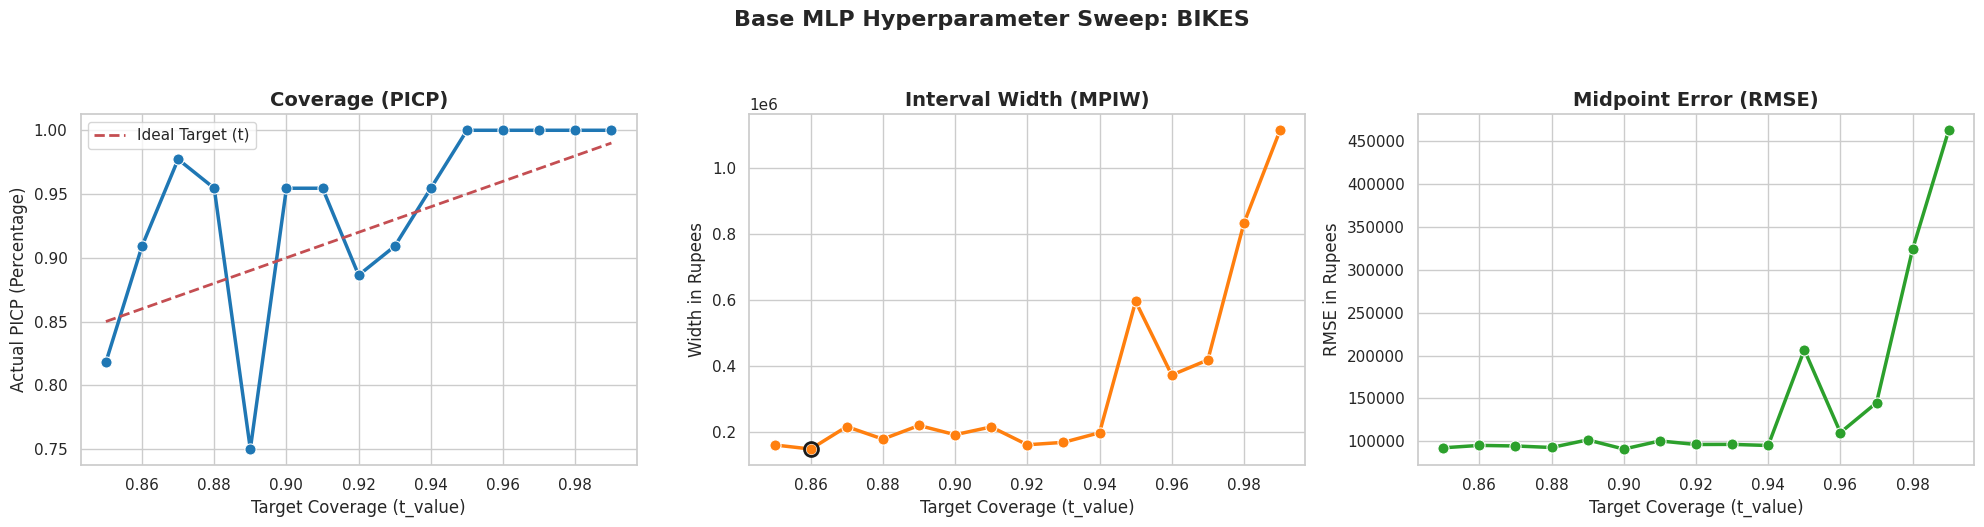

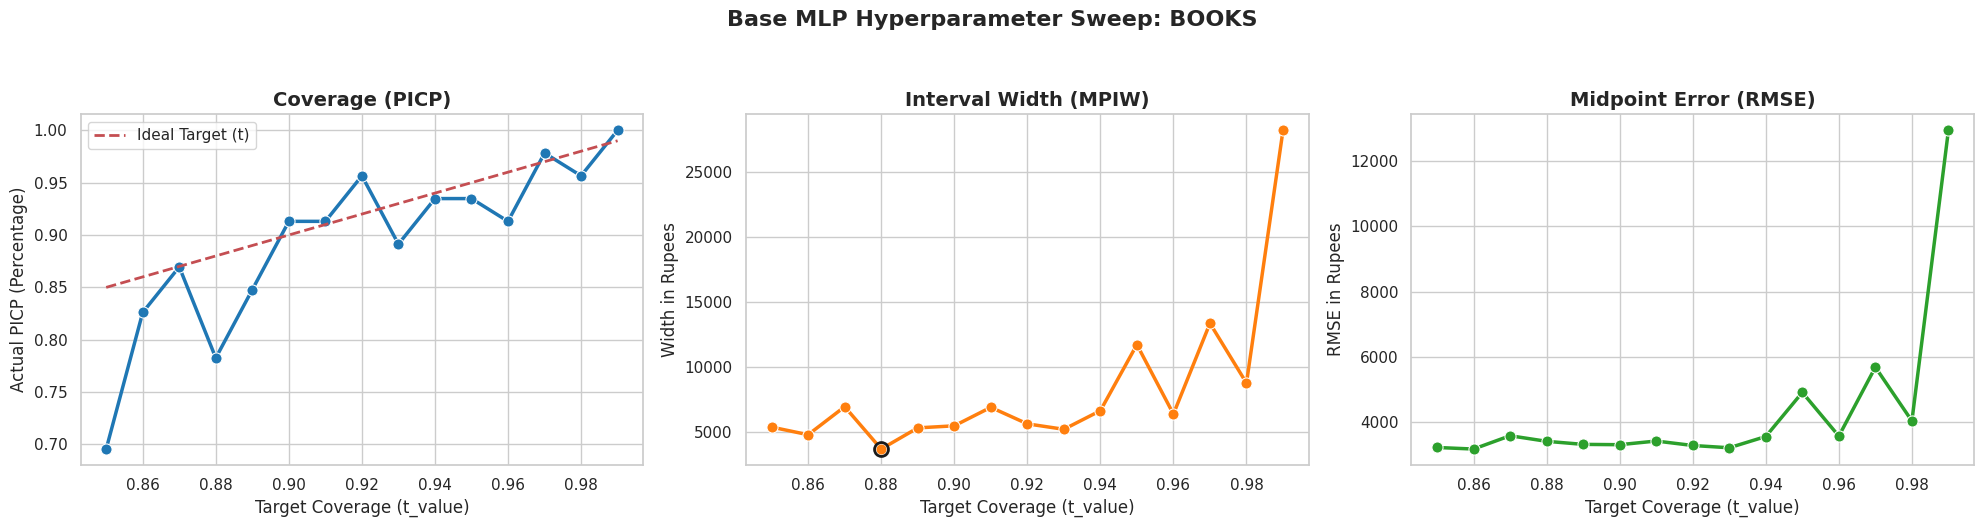

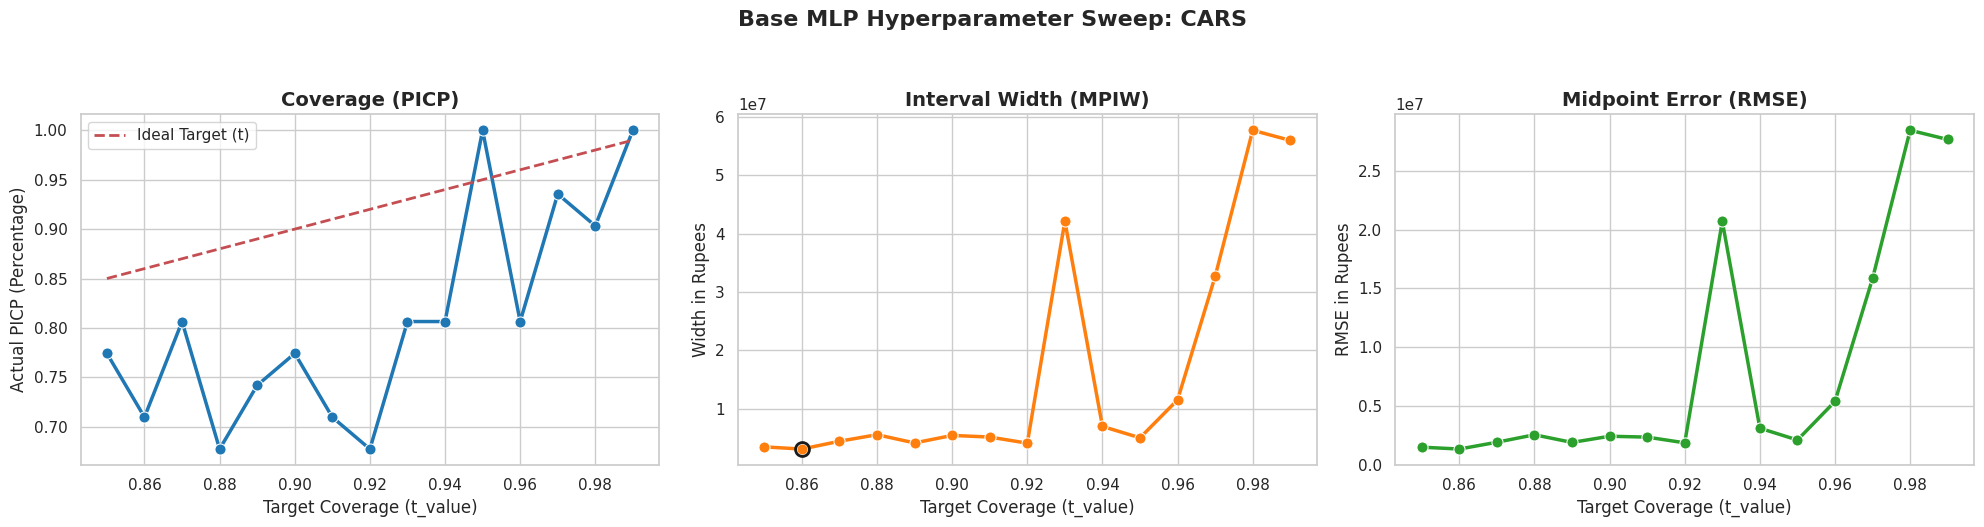

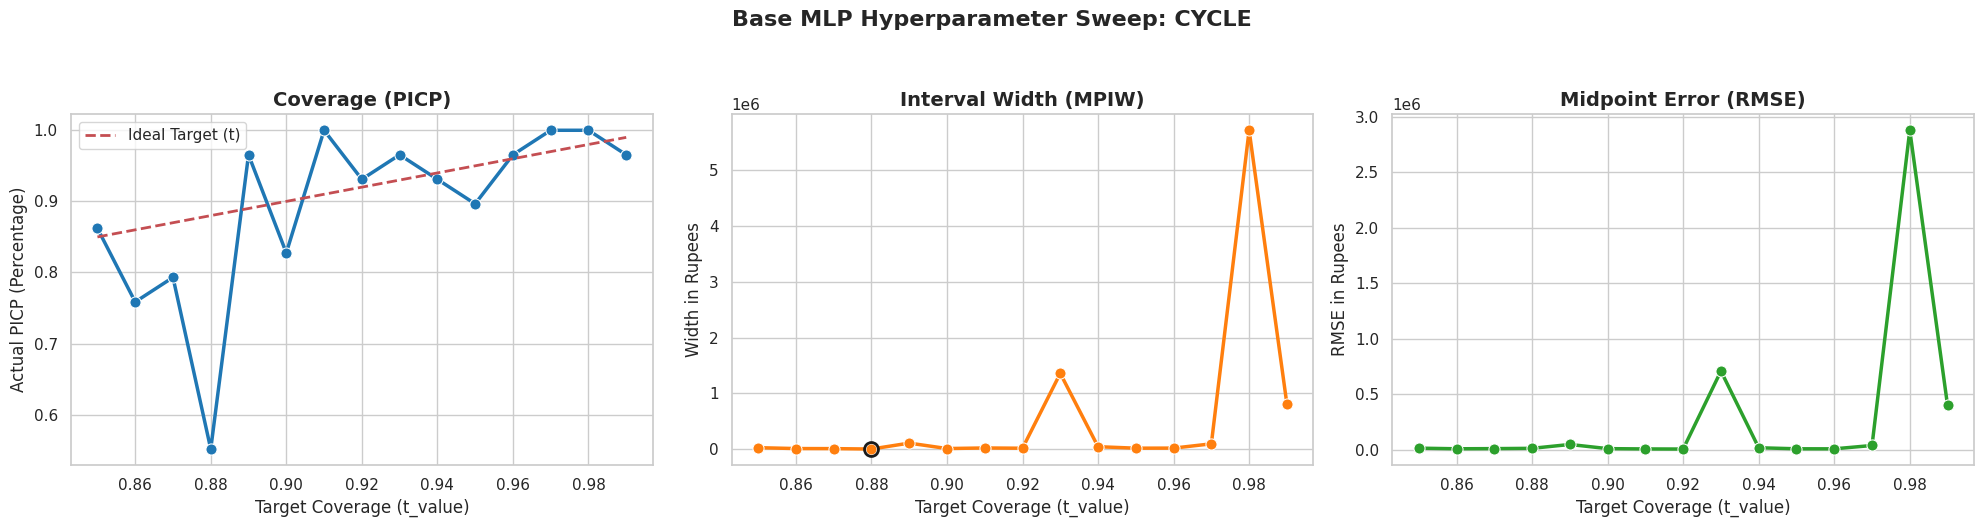

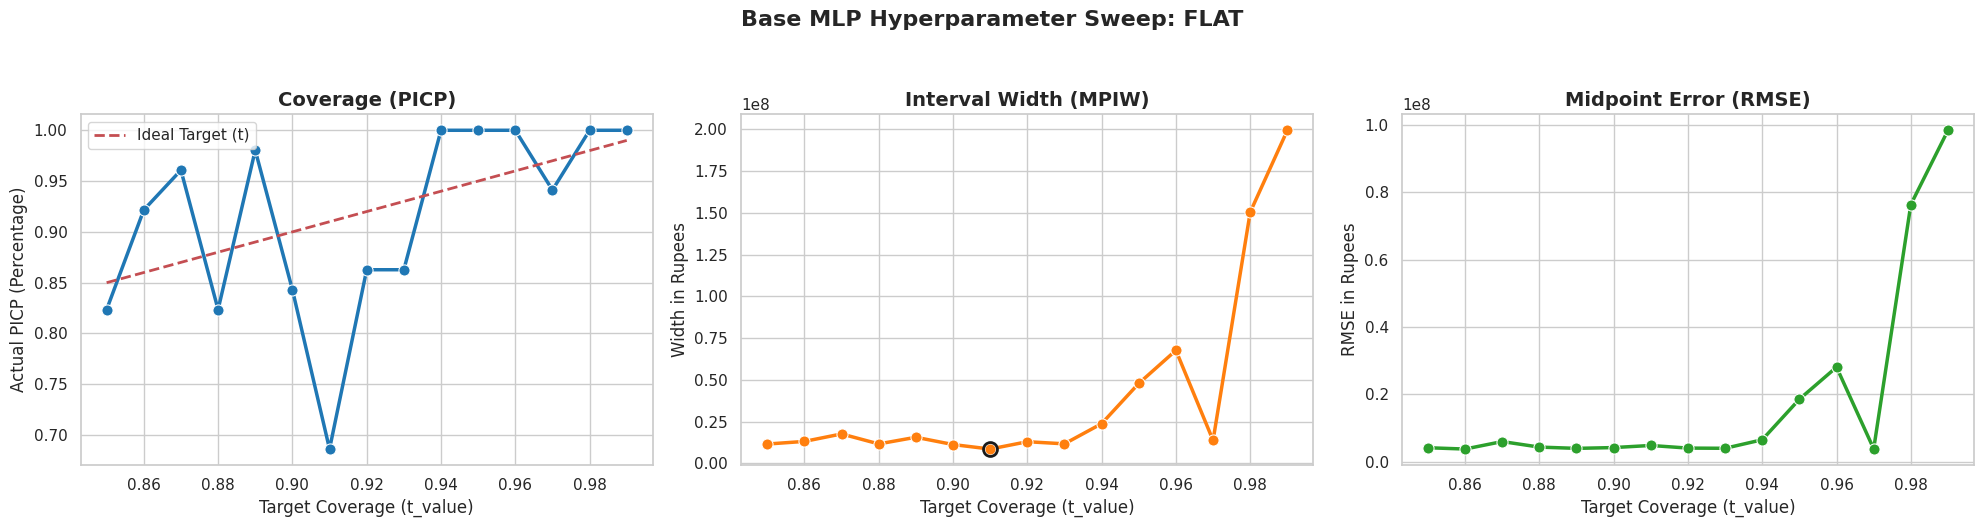

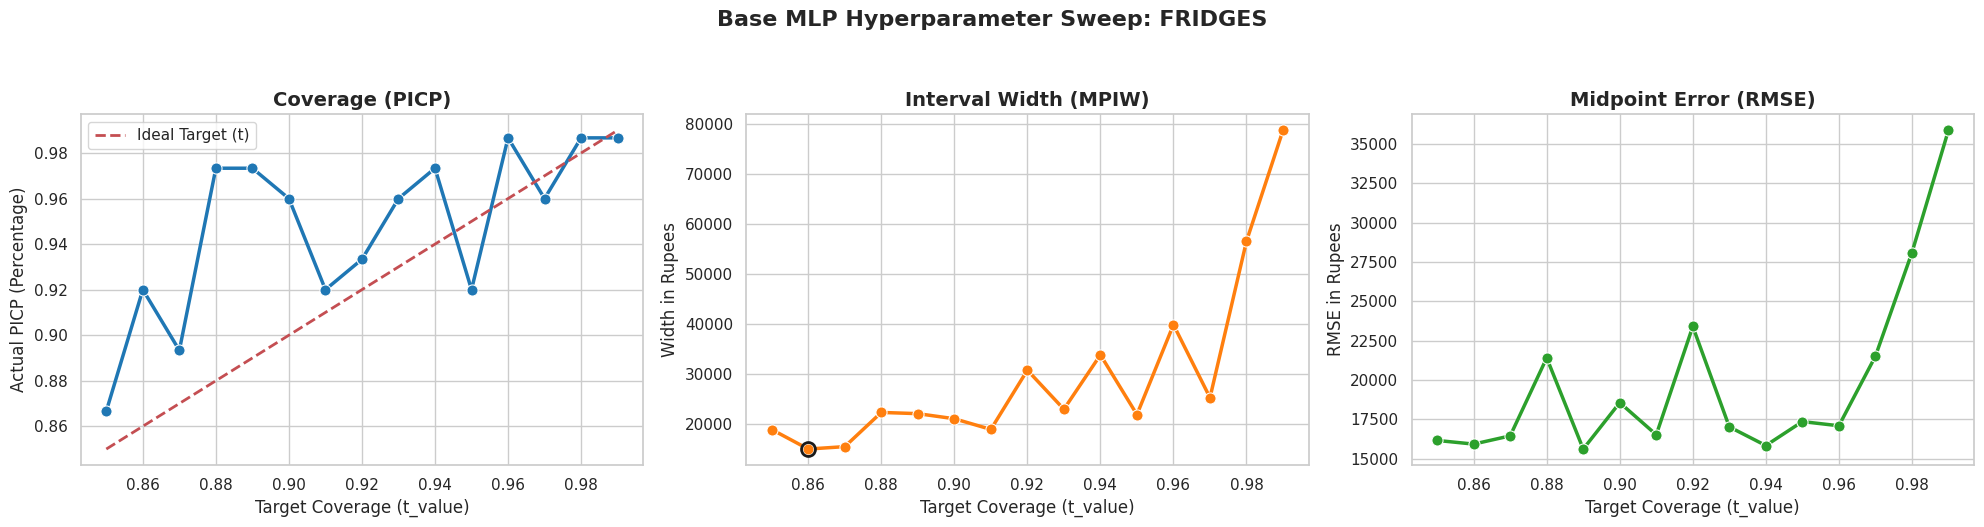

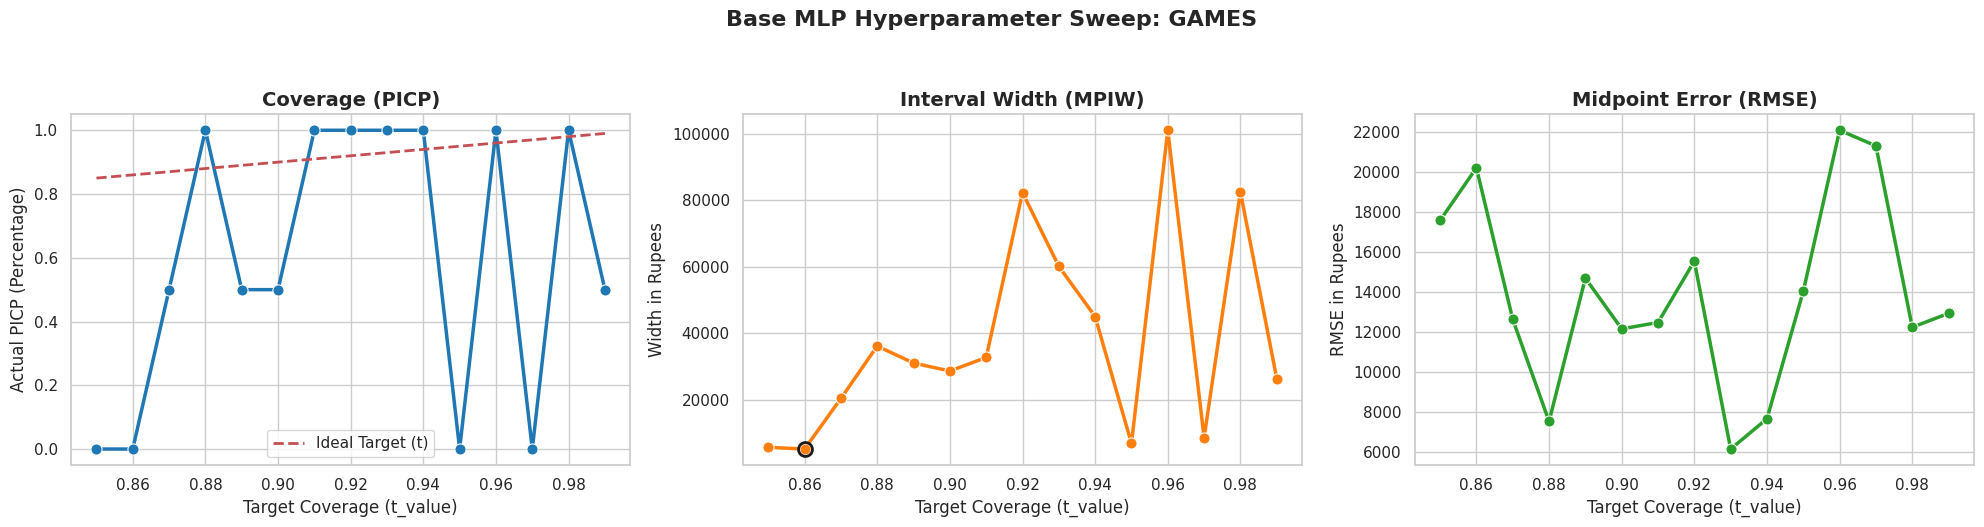

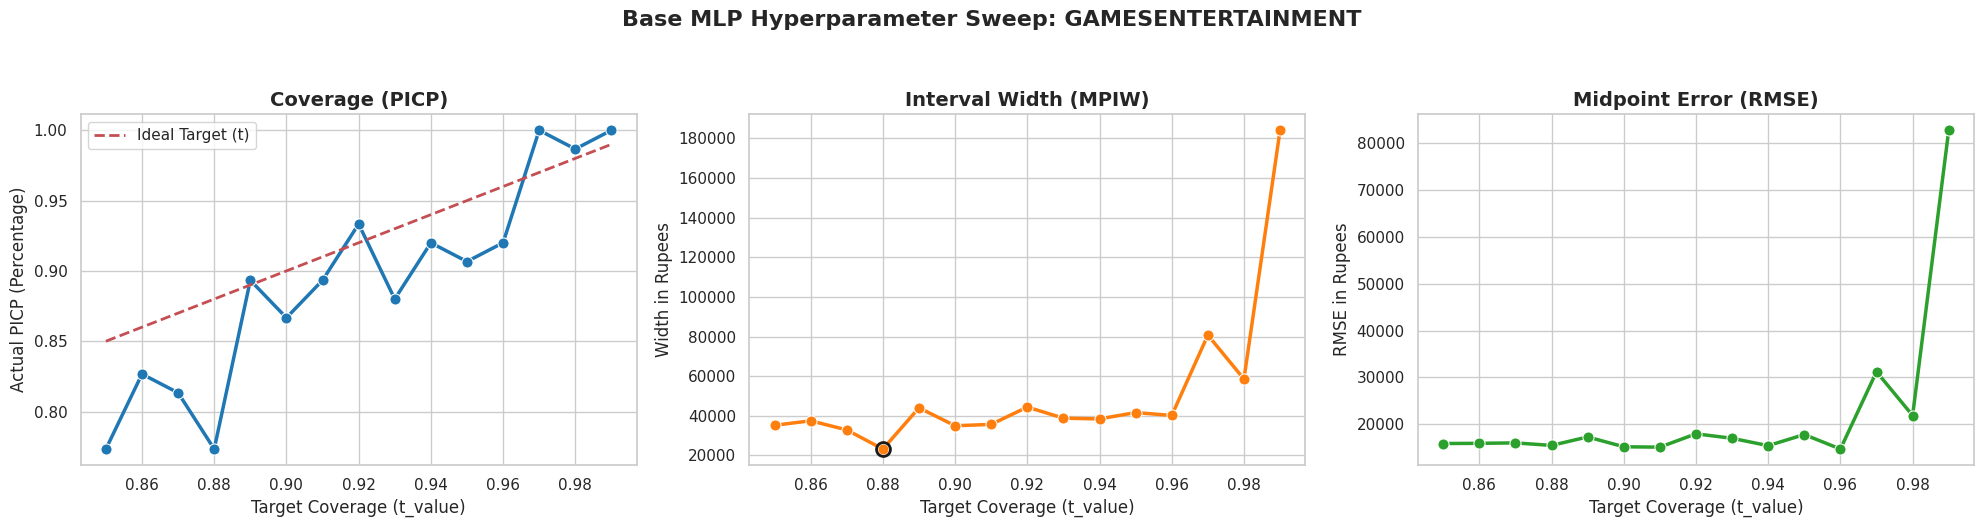

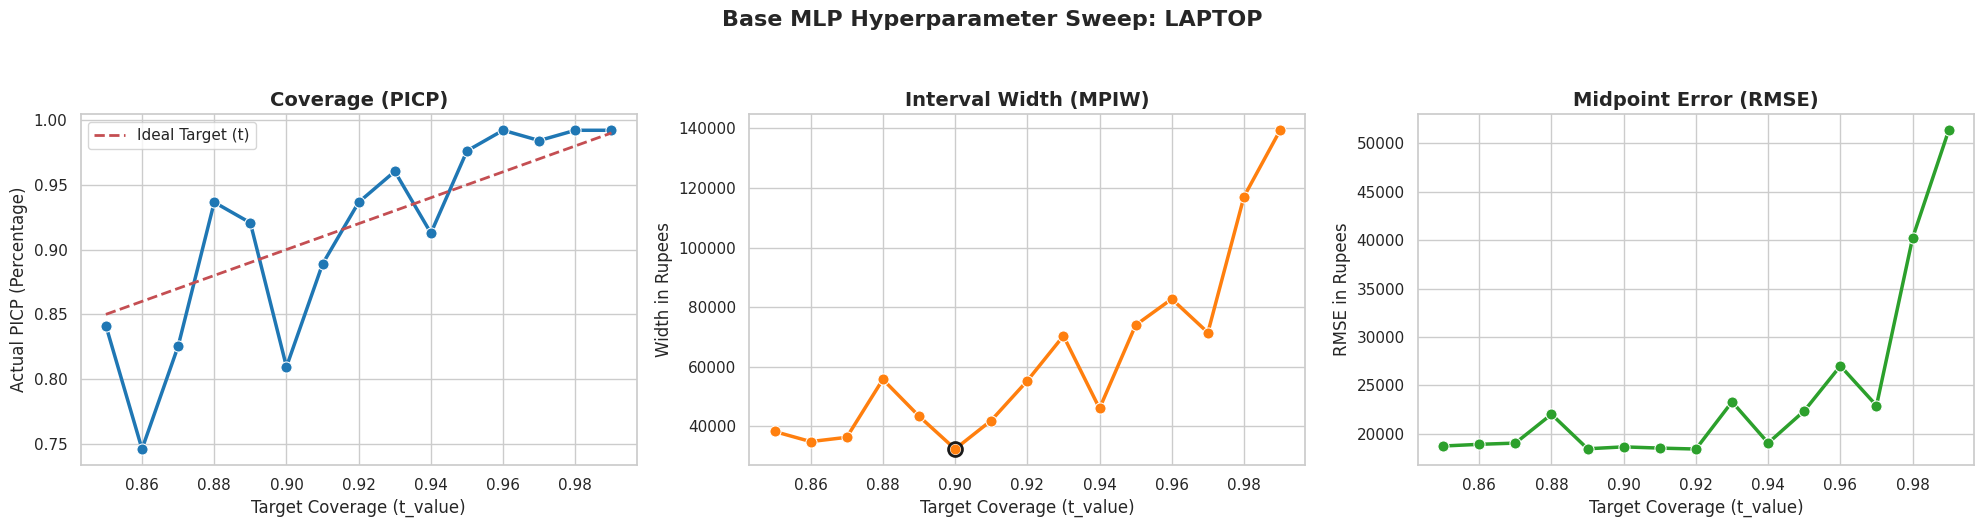

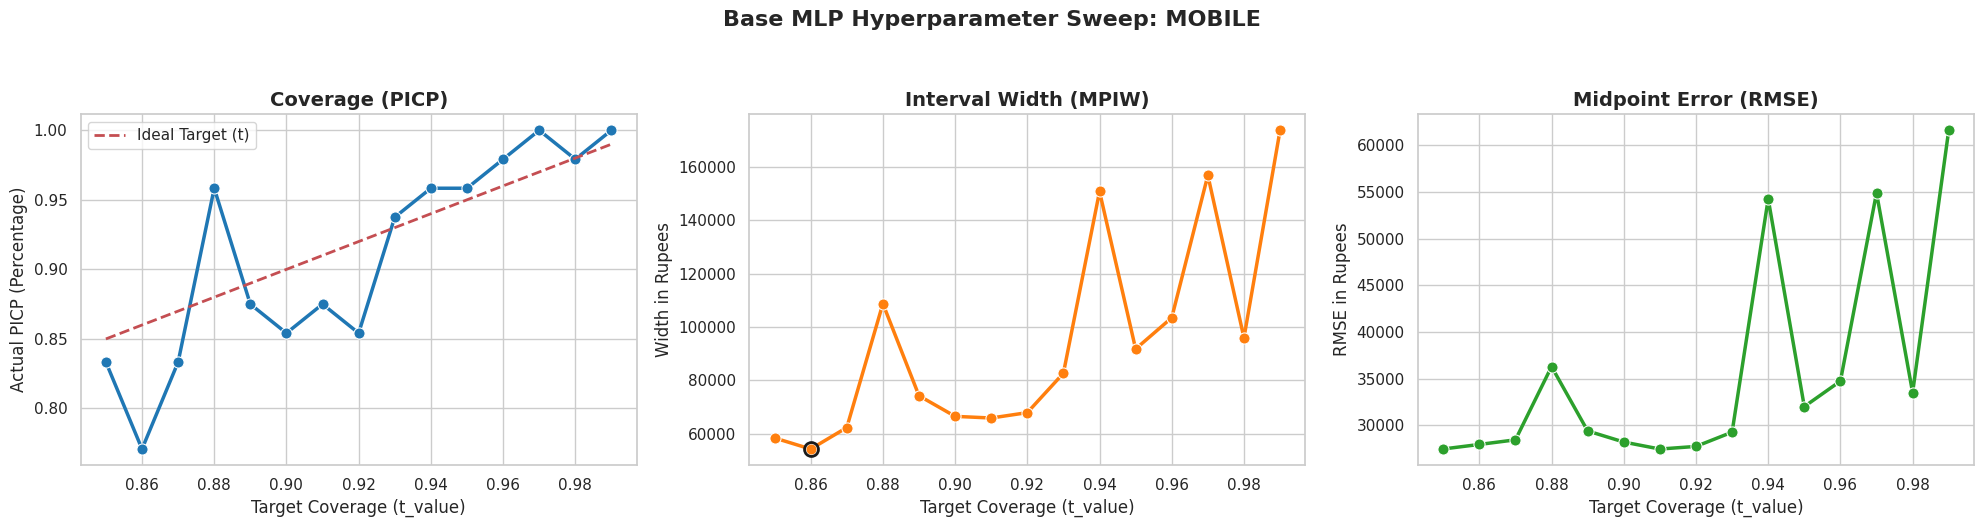

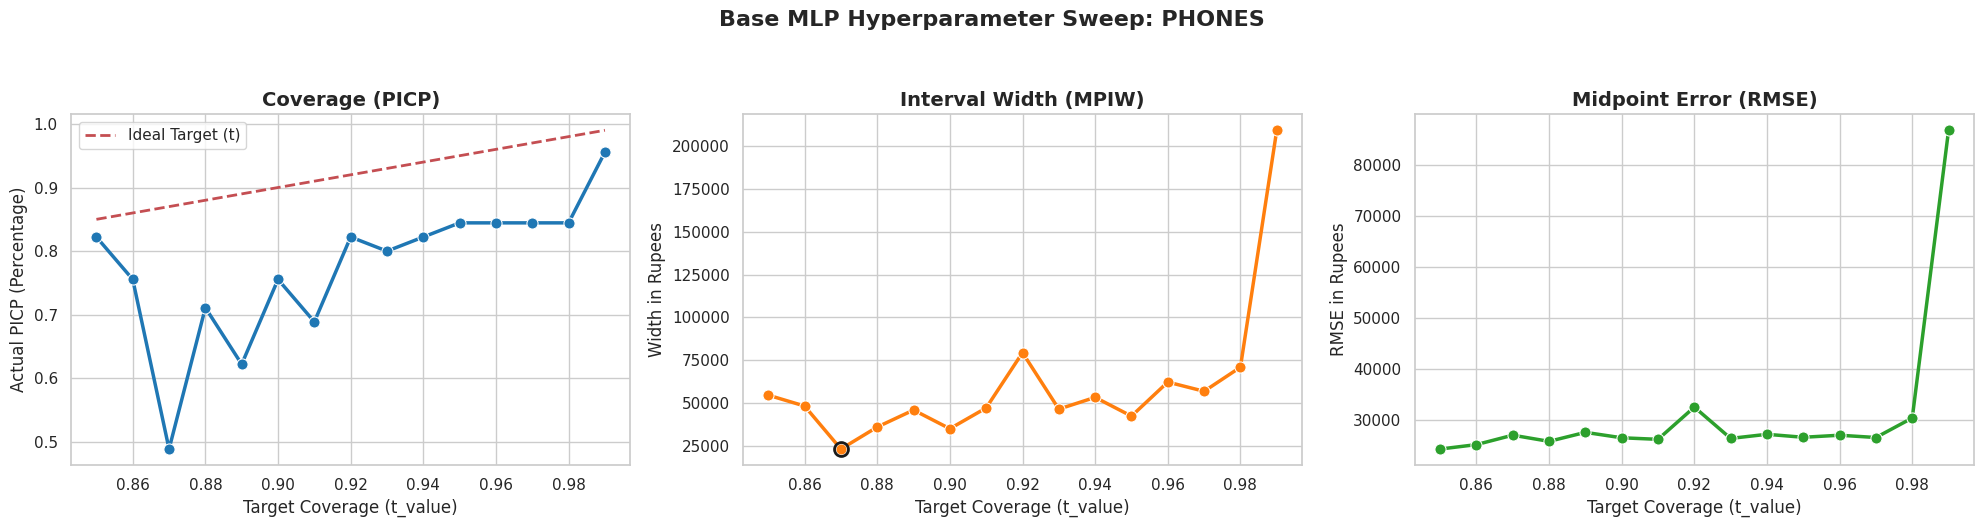

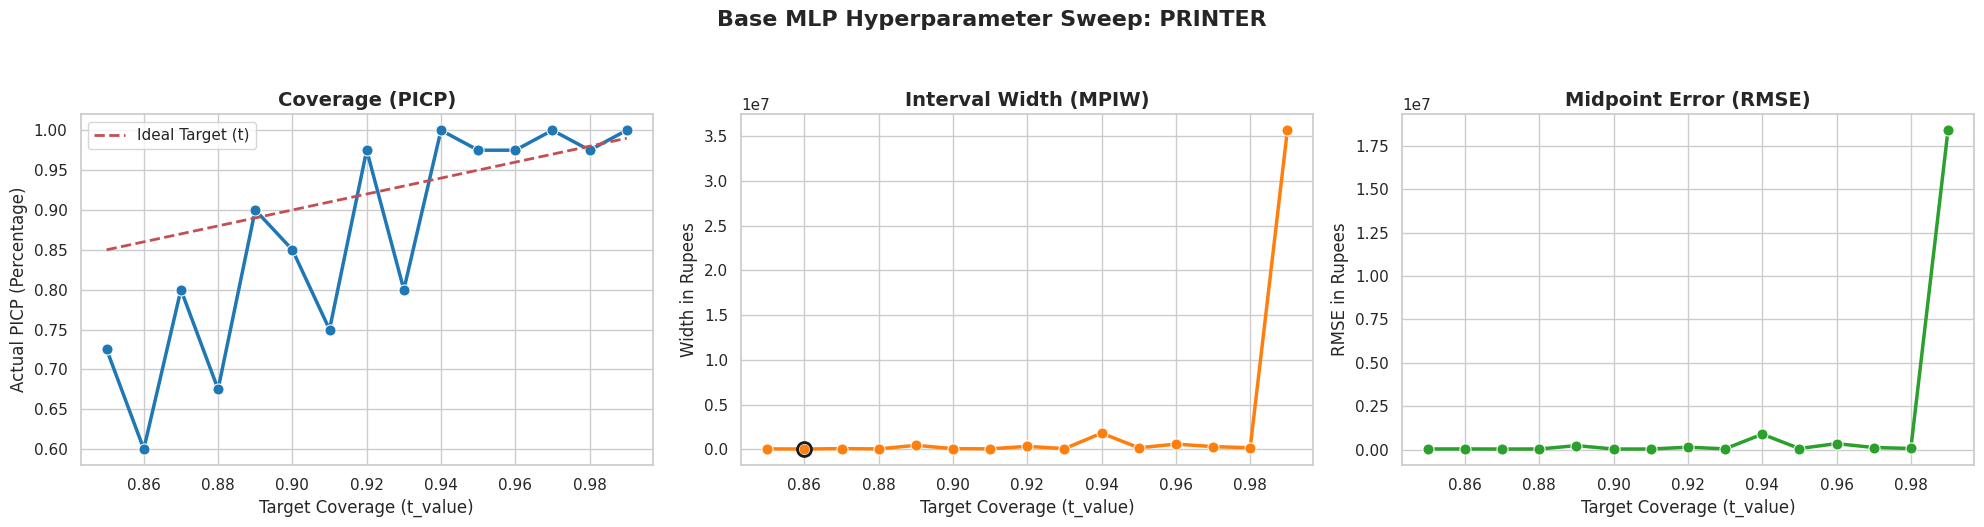

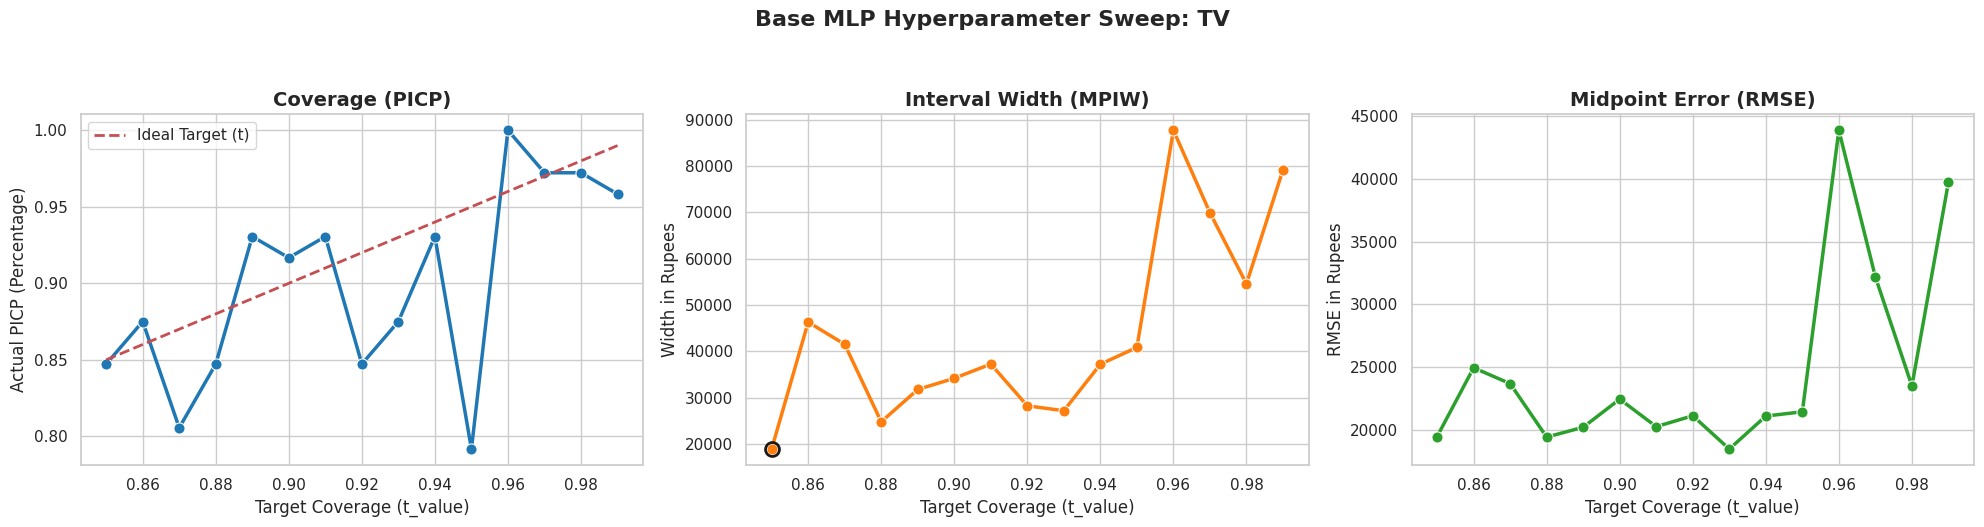

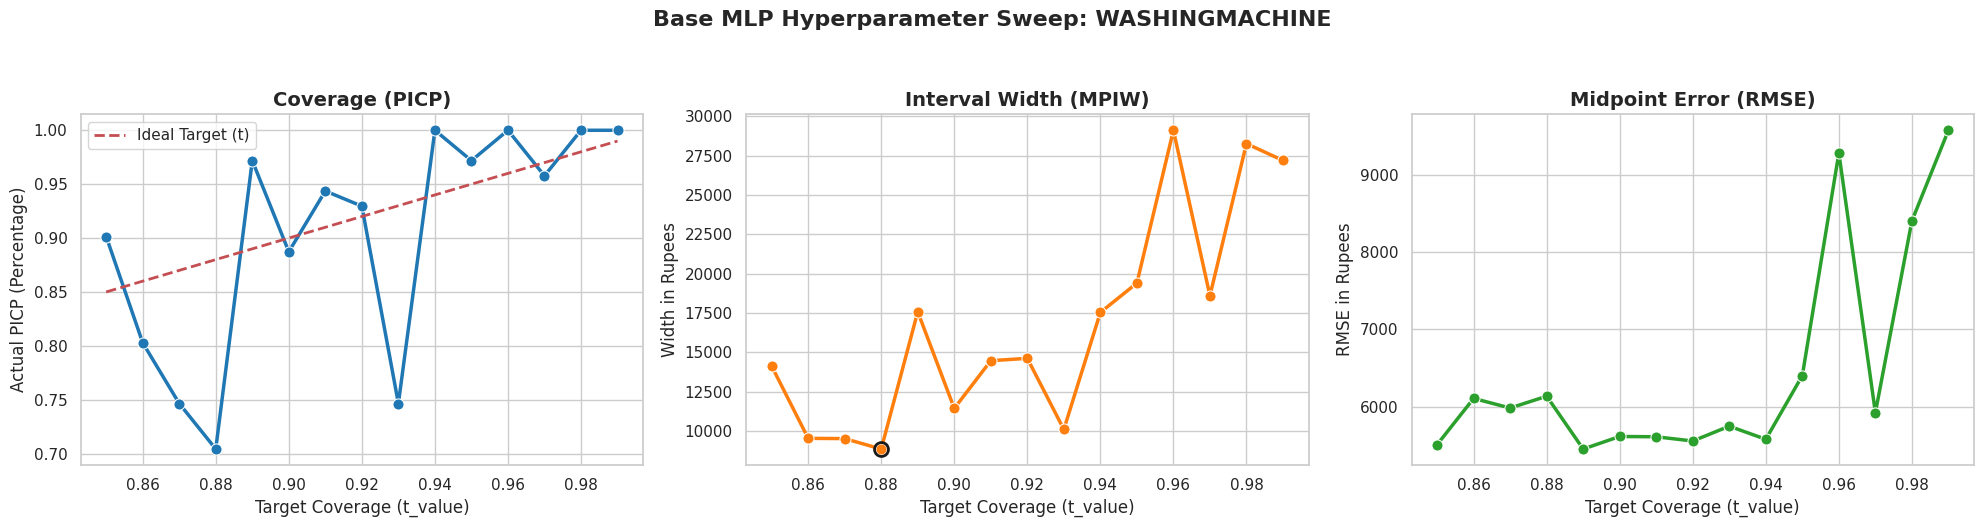

In [111]:
def plot_granular_sweep(df):
    sns.set_theme(style="whitegrid")
    categories = df['Category'].unique()
    
    for cat in categories:
        cat_df = df[df['Category'] == cat]
        
        fig, axes = plt.subplots(1, 3, figsize=(20, 5))
        fig.suptitle(f"Base MLP Hyperparameter Sweep: {cat}", fontsize=16, fontweight='bold', y=1.05)
        
        sns.lineplot(data=cat_df, x='t_value', y='PICP', marker='o', ax=axes[0], color='#1f77b4', linewidth=2.5, markersize=8)
        axes[0].plot([cat_df['t_value'].min(), cat_df['t_value'].max()], 
                     [cat_df['t_value'].min(), cat_df['t_value'].max()], 
                     'r--', label='Ideal Target (t)', linewidth=2)
        axes[0].set_title("Coverage (PICP)", fontsize=14, fontweight='bold')
        axes[0].set_ylabel("Actual PICP (Percentage)", fontsize=12)
        axes[0].set_xlabel("Target Coverage (t_value)", fontsize=12)
        axes[0].legend()
        
        sns.lineplot(data=cat_df, x='t_value', y='MPIW', marker='o', ax=axes[1], color='#ff7f0e', linewidth=2.5, markersize=8)
        axes[1].set_title("Interval Width (MPIW)", fontsize=14, fontweight='bold')
        axes[1].set_ylabel("Width in Rupees", fontsize=12)
        axes[1].set_xlabel("Target Coverage (t_value)", fontsize=12)
        
        min_mpiw_idx = cat_df['MPIW'].idxmin()
        axes[1].plot(cat_df.loc[min_mpiw_idx, 't_value'], cat_df.loc[min_mpiw_idx, 'MPIW'], 'ko', markersize=10, fillstyle='none', markeredgewidth=2)
        
        sns.lineplot(data=cat_df, x='t_value', y='RMSE', marker='o', ax=axes[2], color='#2ca02c', linewidth=2.5, markersize=8)
        axes[2].set_title("Midpoint Error (RMSE)", fontsize=14, fontweight='bold')
        axes[2].set_ylabel("RMSE in Rupees", fontsize=12)
        axes[2].set_xlabel("Target Coverage (t_value)", fontsize=12)
        
        plt.tight_layout()
        plt.show()

# Generate the plots
plot_granular_sweep(df_sweep_results)

In [70]:
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
print(f"Using device: {torch.cuda.get_device_name(0)}")
torch.cuda.empty_cache()

Using device: NVIDIA H100 PCIe


In [14]:
def train_custom_t_base_models(split_dir="split_embeddings", epochs=5):
    # device = "cuda" if torch.cuda.is_available() else "cpu"
    device="cpu"
    print(f"Using device: {device}\n")
    
    category_t_map = {
        "BIKES": 0.94,
        "BOOKS": 0.97,
        "CARS": 0.95,
        "CYCLE": 0.96,
        "FLAT": 0.94,
        "FRIDGES": 0.94,
        "GAMES": 0.94,
        "GAMESENTERTAINMENT": 0.97,
        "LAPTOP": 0.95,
        "MOBILE": 0.95,
        "PHONES": 0.98,
        "PRINTER": 0.95,
        "TV": 0.96,
        "WASHINGMACHINE": 0.94
    }
    
    train_files = [f for f in os.listdir(os.path.join(split_dir, 'train')) if f.endswith('.pt')]
    
    for file in train_files:
        cat_name = file.replace('combined_', '').replace('.pt', '').upper()
        train_path = os.path.join(split_dir, 'train', file)
        test_path = os.path.join(split_dir, 'test', file)
        
        if not os.path.exists(test_path):
            continue
            
        # Fetch the custom t_val (defaulting to 0.95 just in case a category is missing)
        t_val = category_t_map.get(cat_name, 0.95)
        
        print(f"{'-'*60}")
        print(f"TRAINING: {cat_name} | Target Coverage (t) = {t_val}")
        
        raw_train_data = torch.load(train_path, weights_only=False)
        cat_mu = raw_train_data['log_prices'].mean().item()
        cat_sigma = raw_train_data['log_prices'].std().item()
        
        train_dataset = ScaledRFPDataset(train_path, cat_mu, cat_sigma)
        test_dataset = ScaledRFPDataset(test_path, cat_mu, cat_sigma)
        
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
        
        model = CategoryHeadModel().to(device)
        optimizer = AdamW(model.parameters(), lr=1e-3)
        
        model.train()
        for epoch in range(epochs):
            total_loss = 0
            for x, y in train_loader:
                x, y = x.to(device), y.to(device)
                optimizer.zero_grad()
                out = model(x)
                
                loss = tube_loss(y, out[:,0], out[:,1], t=t_val, r=0.5)
                
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
        
        model.eval()
        lowers, uppers, ys = [], [], []
        with torch.no_grad():
            for x_batch, y_batch in test_loader:
                out = model(x_batch.to(device))
                
                l = torch.exp(torch.min(out[:,0], out[:,1]) * cat_sigma + cat_mu)
                u = torch.exp(torch.max(out[:,0], out[:,1]) * cat_sigma + cat_mu)
                y_true = torch.exp(y_batch.to(device) * cat_sigma + cat_mu)
                
                lowers.append(l)
                uppers.append(u)
                ys.append(y_true)
                
        l_preds = torch.cat(lowers)
        u_preds = torch.cat(uppers)
        y_trues = torch.cat(ys)
        
        # Calculate final metrics
        picp = ((y_trues >= l_preds) & (y_trues <= u_preds)).float().mean().item()
        mpiw = (u_preds - l_preds).mean().item()
        mid_preds = (l_preds + u_preds) / 2.0
        rmse = torch.sqrt(torch.mean((y_trues - mid_preds) ** 2)).item()
        
        print(f"-> FINAL PICP: {picp:.4f}")
        print(f"-> FINAL MPIW: {mpiw:.2f}")
        print(f"-> FINAL RMSE: {rmse:.2f}\n")


In [16]:
train_custom_t_base_models(epochs=5)

Using device: cpu

------------------------------------------------------------
TRAINING: BIKES | Target Coverage (t) = 0.94
-> FINAL PICP: 0.9773
-> FINAL MPIW: 364245.47
-> FINAL RMSE: 120056.38

------------------------------------------------------------
TRAINING: BOOKS | Target Coverage (t) = 0.97
-> FINAL PICP: 0.9130
-> FINAL MPIW: 7841.54
-> FINAL RMSE: 3867.51

------------------------------------------------------------
TRAINING: CARS | Target Coverage (t) = 0.95
-> FINAL PICP: 0.8710
-> FINAL MPIW: 6878213.50
-> FINAL RMSE: 3037729.00

------------------------------------------------------------
TRAINING: CYCLE | Target Coverage (t) = 0.96
-> FINAL PICP: 0.9655
-> FINAL MPIW: 60133.25
-> FINAL RMSE: 21675.87

------------------------------------------------------------
TRAINING: FLAT | Target Coverage (t) = 0.94
-> FINAL PICP: 0.9608
-> FINAL MPIW: 18954168.00
-> FINAL RMSE: 5055754.00

------------------------------------------------------------
TRAINING: FRIDGES | Target C

In [19]:
torch.cuda.empty_cache()
torch.manual_seed(54)
train_custom_t_base_models(epochs=5)

Using device: cpu

------------------------------------------------------------
TRAINING: BIKES | Target Coverage (t) = 0.94
-> FINAL PICP: 1.0000
-> FINAL MPIW: 282387.44
-> FINAL RMSE: 81856.73

------------------------------------------------------------
TRAINING: BOOKS | Target Coverage (t) = 0.97
-> FINAL PICP: 1.0000
-> FINAL MPIW: 15665.35
-> FINAL RMSE: 6716.47

------------------------------------------------------------
TRAINING: CARS | Target Coverage (t) = 0.95
-> FINAL PICP: 0.9355
-> FINAL MPIW: 11694187.00
-> FINAL RMSE: 5361730.50

------------------------------------------------------------
TRAINING: CYCLE | Target Coverage (t) = 0.96
-> FINAL PICP: 0.9310
-> FINAL MPIW: 40677.04
-> FINAL RMSE: 17668.11

------------------------------------------------------------
TRAINING: FLAT | Target Coverage (t) = 0.94
-> FINAL PICP: 1.0000
-> FINAL MPIW: 43774392.00
-> FINAL RMSE: 16455186.00

------------------------------------------------------------
TRAINING: FRIDGES | Target

In [53]:
import os
import torch
import pandas as pd
import numpy as np
import lightgbm as lgb
from torch.optim import AdamW
from torch.utils.data import DataLoader
import warnings
warnings.filterwarnings('ignore')

def train_and_evaluate_custom_ensemble(split_dir="split_embeddings", epochs=5):
    # Using CPU to avoid the shared server VRAM crashes
    device = "cpu"
    print(f"Using device: {device}\n")
    
    category_t_map = {
        "BIKES": 0.94,
        "BOOKS": 0.97,
        "CARS": 0.95,
        "CYCLE": 0.96,
        "FLAT": 0.94,
        "FRIDGES": 0.94,
        "GAMES": 0.94,
        "GAMESENTERTAINMENT": 0.97,
        "LAPTOP": 0.95,
        "MOBILE": 0.95,
        "PHONES": 0.98,
        "PRINTER": 0.95,
        "TV": 0.96,
        "WASHINGMACHINE": 0.94
    }
    
    train_files = [f for f in os.listdir(os.path.join(split_dir, 'train')) if f.endswith('.pt')]
    
    for file in train_files:
        cat_name = file.replace('combined_', '').replace('.pt', '').upper()
        train_path = os.path.join(split_dir, 'train', file)
        test_path = os.path.join(split_dir, 'test', file)
        
        if not os.path.exists(test_path):
            continue
            
        t_val = category_t_map.get(cat_name, 0.95)
        
        print(f"\n{'-'*60}")
        print(f"ENSEMBLE TRAINING: {cat_name} | Target Coverage (t) = {t_val}")
        print(f"{'-'*60}")
        
        # 1. Load Data
        raw_train_data = torch.load(train_path, weights_only=False)
        cat_mu = raw_train_data['log_prices'].mean().item()
        cat_sigma = raw_train_data['log_prices'].std().item()
        
        train_dataset = ScaledRFPDataset(train_path, cat_mu, cat_sigma)
        test_dataset = ScaledRFPDataset(test_path, cat_mu, cat_sigma)
        
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
        
        # ==========================================
        # MODEL 1: Base MLP
        # ==========================================
        model_base = CategoryHeadModel().to(device)
        opt_base = AdamW(model_base.parameters(), lr=1e-3)
        model_base.train()
        for epoch in range(epochs):
            for x, y in train_loader:
                x, y = x.to(device), y.to(device)
                opt_base.zero_grad()
                out = model_base(x)
                loss = tube_loss(y, out[:,0], out[:,1], t=t_val, r=0.5)
                loss.backward()
                opt_base.step()

        # ==========================================
        # MODEL 2: Residual MLP
        # ==========================================
        model_res = ResidualCategoryHead().to(device)
        opt_res = AdamW(model_res.parameters(), lr=1e-3)
        model_res.train()
        for epoch in range(epochs):
            for x, y in train_loader:
                x, y = x.to(device), y.to(device)
                opt_res.zero_grad()
                out = model_res(x)
                loss = tube_loss(y, out[:,0], out[:,1], t=t_val, r=0.5)
                loss.backward()
                opt_res.step()

        # ==========================================
        # MODEL 3: LightGBM Quantile Trees
        # ==========================================
        X_np = raw_train_data['embeddings'].numpy()
        y_np = train_dataset.targets.numpy()
        
        # LightGBM gets the exact custom t_val for its quantiles!
        # If t=0.94, lower predicts 6th percentile (1 - 0.94) and upper predicts 94th percentile
        lgb_lower = lgb.LGBMRegressor(objective='quantile', alpha=1-t_val, n_estimators=100, random_state=42, verbose=-1)
        lgb_upper = lgb.LGBMRegressor(objective='quantile', alpha=t_val, n_estimators=100, random_state=42, verbose=-1)
        
        # Wrapping in try-except in case a category has too few samples (like GAMES)
        try:
            lgb_lower.fit(X_np, y_np)
            lgb_upper.fit(X_np, y_np)
            use_lgb = True
        except Exception:
            use_lgb = False

        # ==========================================
        # EVALUATION (Mean Bounding Ensemble)
        # ==========================================
        model_base.eval()
        model_res.eval()
        
        lowers_ens, uppers_ens, ys = [], [], []
        
        with torch.no_grad():
            for x_batch, y_batch in test_loader:
                x_device = x_batch.to(device)
                x_np = x_batch.numpy()
                
                # 1. Base MLP Bounds
                out_base = model_base(x_device)
                l_base = torch.min(out_base[:,0], out_base[:,1])
                u_base = torch.max(out_base[:,0], out_base[:,1])
                
                # 2. Residual MLP Bounds
                out_res = model_res(x_device)
                l_res = torch.min(out_res[:,0], out_res[:,1])
                u_res = torch.max(out_res[:,0], out_res[:,1])
                
                # 3. LightGBM Bounds
                if use_lgb:
                    l_lgb = torch.tensor(lgb_lower.predict(x_np), dtype=torch.float32).to(device)
                    u_lgb = torch.tensor(lgb_upper.predict(x_np), dtype=torch.float32).to(device)
                    
                    batch_lowers = torch.stack([l_base, l_res, l_lgb])
                    batch_uppers = torch.stack([u_base, u_res, u_lgb])
                else:
                    # Fallback to just PyTorch models if LightGBM couldn't train (e.g., small dataset)
                    batch_lowers = torch.stack([l_base, l_res])
                    batch_uppers = torch.stack([u_base, u_res])

                # MEAN BOUNDING (To actively shrink the width)
                mean_l = torch.mean(batch_lowers, dim=0)
                mean_u = torch.mean(batch_uppers, dim=0)
                
                # Inverse Transform to real Rupees
                l_real = torch.exp(mean_l * cat_sigma + cat_mu)
                u_real = torch.exp(mean_u * cat_sigma + cat_mu)
                y_true = torch.exp(y_batch.to(device) * cat_sigma + cat_mu)
                
                lowers_ens.append(l_real)
                uppers_ens.append(u_real)
                ys.append(y_true)
                
        l_preds = torch.cat(lowers_ens)
        u_preds = torch.cat(uppers_ens)
        y_trues = torch.cat(ys)
        
        # Calculate final metrics
        picp = ((y_trues >= l_preds) & (y_trues <= u_preds)).float().mean().item()
        mpiw = (u_preds - l_preds).mean().item()
        mid_preds = (l_preds + u_preds) / 2.0
        rmse = torch.sqrt(torch.mean((y_trues - mid_preds) ** 2)).item()
        
        print(f"-> FINAL ENSEMBLE PICP: {picp:.4f}")
        print(f"-> FINAL ENSEMBLE MPIW: {mpiw:.2f}")
        print(f"-> FINAL ENSEMBLE RMSE: {rmse:.2f}\n")

torch.manual_seed(54)
train_and_evaluate_custom_ensemble(epochs=5)

Using device: cpu


------------------------------------------------------------
ENSEMBLE TRAINING: BIKES | Target Coverage (t) = 0.94
------------------------------------------------------------
-> FINAL ENSEMBLE PICP: 0.9773
-> FINAL ENSEMBLE MPIW: 272006.28
-> FINAL ENSEMBLE RMSE: 88263.74


------------------------------------------------------------
ENSEMBLE TRAINING: BOOKS | Target Coverage (t) = 0.97
------------------------------------------------------------
-> FINAL ENSEMBLE PICP: 0.9565
-> FINAL ENSEMBLE MPIW: 10874.48
-> FINAL ENSEMBLE RMSE: 4607.31


------------------------------------------------------------
ENSEMBLE TRAINING: CARS | Target Coverage (t) = 0.95
------------------------------------------------------------
-> FINAL ENSEMBLE PICP: 1.0000
-> FINAL ENSEMBLE MPIW: 4255395.00
-> FINAL ENSEMBLE RMSE: 1610248.38


------------------------------------------------------------
ENSEMBLE TRAINING: CYCLE | Target Coverage (t) = 0.96
-------------------------------------

In [52]:
import os
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import DataLoader
import pandas as pd

# ==========================================
# 1. THE ARCHITECTURES (BUILT FOR EMBEDDINGS)
# ==========================================

# Model 1: The Reliable Baseline
class CategoryHeadModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(1536, 512), nn.LayerNorm(512), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(512, 256), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(256, 2)
        )
    def forward(self, x): return self.head(x)

# Model 2: Residual Network (Prevents feature loss)
class ResidualCategoryHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Linear(1536, 512), nn.LayerNorm(512), nn.GELU(), nn.Dropout(0.2)
        )
        self.layer2 = nn.Sequential(
            nn.Linear(512, 512), nn.LayerNorm(512), nn.GELU(), nn.Dropout(0.1)
        )
        self.out = nn.Linear(512, 2)
        
    def forward(self, x):
        h1 = self.layer1(x)
        h2 = self.layer2(h1) + h1 # Skip connection adds the original features back in
        return self.out(h2)

# Model 3: Wide & Shallow Network (Finds different correlations)
class WideCategoryHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(1536, 1024), nn.LayerNorm(1024), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(1024, 2)
        )
    def forward(self, x): return self.head(x)


# ==========================================
# 2. TRAINING & EVALUATION LOOP
# ==========================================
def train_upgraded_nn_ensemble(split_dir="split_embeddings", epochs=5):
    device = "cpu"
    print(f"Using device: {device}\n")
    
    category_t_map = {
        "BIKES": 0.95, "BOOKS": 0.96, "CARS": 0.97, "CYCLE": 0.96,
        "FLAT": 0.97, "FRIDGES": 0.97, "GAMES": 0.97, "GAMESENTERTAINMENT": 0.95,
        "LAPTOP": 0.97, "MOBILE": 0.95, "PHONES": 0.95, "PRINTER": 0.97,
        "TV": 0.96, "WASHINGMACHINE": 0.94
    }
    
    train_files = [f for f in os.listdir(os.path.join(split_dir, 'train')) if f.endswith('.pt')]
    
    for file in train_files:
        cat_name = file.replace('combined_', '').replace('.pt', '').upper()
        train_path = os.path.join(split_dir, 'train', file)
        test_path = os.path.join(split_dir, 'test', file)
        
        if not os.path.exists(test_path): continue
            
        t_val = category_t_map.get(cat_name, 0.95)
        print(f"\n{'-'*60}\nUPGRADED NN ENSEMBLE: {cat_name} | Target (t) = {t_val}\n{'-'*60}")
        
        # Load Data
        raw_train_data = torch.load(train_path, weights_only=False)
        cat_mu = raw_train_data['log_prices'].mean().item()
        cat_sigma = raw_train_data['log_prices'].std().item()
        
        train_dataset = ScaledRFPDataset(train_path, cat_mu, cat_sigma)
        test_dataset = ScaledRFPDataset(test_path, cat_mu, cat_sigma)
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
        
        # Initialize Models
        model_base = CategoryHeadModel().to(device)
        model_res = ResidualCategoryHead().to(device)
        model_wide = WideCategoryHead().to(device)
        
        opt_base = AdamW(model_base.parameters(), lr=1e-3)
        opt_res = AdamW(model_res.parameters(), lr=1e-3)
        opt_wide = AdamW(model_wide.parameters(), lr=1e-3)

        # Train Models
        model_base.train(); model_res.train(); model_wide.train()
        for epoch in range(epochs):
            for x, y in train_loader:
                x, y = x.to(device), y.to(device)
                
                # Base
                opt_base.zero_grad()
                out_base = model_base(x)
                loss_base = tube_loss(y, out_base[:,0], out_base[:,1], t=t_val, r=0.5)
                loss_base.backward()
                opt_base.step()
                
                # Residual
                opt_res.zero_grad()
                out_res = model_res(x)
                loss_res = tube_loss(y, out_res[:,0], out_res[:,1], t=t_val, r=0.5)
                loss_res.backward()
                opt_res.step()

                # Wide
                opt_wide.zero_grad()
                out_wide = model_wide(x)
                loss_wide = tube_loss(y, out_wide[:,0], out_wide[:,1], t=t_val, r=0.5)
                loss_wide.backward()
                opt_wide.step()

        # Evaluate Models
        model_base.eval(); model_res.eval(); model_wide.eval()
        lowers_ens, uppers_ens, ys = [], [], []
        
        with torch.no_grad():
            for x_batch, y_batch in test_loader:
                x_device = x_batch.to(device)
                
                out_b = model_base(x_device)
                l_b, u_b = torch.min(out_b[:,0], out_b[:,1]), torch.max(out_b[:,0], out_b[:,1])
                
                out_r = model_res(x_device)
                l_r, u_r = torch.min(out_r[:,0], out_r[:,1]), torch.max(out_r[:,0], out_r[:,1])
                
                out_w = model_wide(x_device)
                l_w, u_w = torch.min(out_w[:,0], out_w[:,1]), torch.max(out_w[:,0], out_w[:,1])
                
                batch_lowers = torch.stack([l_b, l_r, l_w])
                batch_uppers = torch.stack([u_b, u_r, u_w])
                
                # SWITCHED TO MEAN: This actively pulls the wider predictions inward
                mean_l = torch.mean(batch_lowers, dim=0)
                mean_u = torch.mean(batch_uppers, dim=0)
                
                # Inverse Transform
                l_real = torch.exp(mean_l * cat_sigma + cat_mu)
                u_real = torch.exp(mean_u * cat_sigma + cat_mu)
                y_true = torch.exp(y_batch.to(device) * cat_sigma + cat_mu)
                
                lowers_ens.append(l_real)
                uppers_ens.append(u_real)
                ys.append(y_true)
                
        l_preds = torch.cat(lowers_ens)
        u_preds = torch.cat(uppers_ens)
        y_trues = torch.cat(ys)
        
        picp = ((y_trues >= l_preds) & (y_trues <= u_preds)).float().mean().item()
        mpiw = (u_preds - l_preds).mean().item()
        mid_preds = (l_preds + u_preds) / 2.0
        rmse = torch.sqrt(torch.mean((y_trues - mid_preds) ** 2)).item()
        
        print(f"-> PICP: {picp:.4f}")
        print(f"-> MPIW: {mpiw:.2f}")
        print(f"-> RMSE: {rmse:.2f}\n")

torch.cuda.empty_cache()
torch.manual_seed(54)
train_upgraded_nn_ensemble(epochs=5)

Using device: cpu


------------------------------------------------------------
UPGRADED NN ENSEMBLE: BIKES | Target (t) = 0.95
------------------------------------------------------------
-> PICP: 1.0000
-> MPIW: 6126014.50
-> RMSE: 3022065.75


------------------------------------------------------------
UPGRADED NN ENSEMBLE: BOOKS | Target (t) = 0.96
------------------------------------------------------------
-> PICP: 1.0000
-> MPIW: 43475.53
-> RMSE: 20055.02


------------------------------------------------------------
UPGRADED NN ENSEMBLE: CARS | Target (t) = 0.97
------------------------------------------------------------
-> PICP: 0.9677
-> MPIW: 18042128.00
-> RMSE: 8583701.00


------------------------------------------------------------
UPGRADED NN ENSEMBLE: CYCLE | Target (t) = 0.96
------------------------------------------------------------
-> PICP: 0.9655
-> MPIW: 1088469.00
-> RMSE: 536999.31


------------------------------------------------------------
UPGRADED NN 

In [50]:
import os
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

class ScaledRFPDataset(Dataset):
    def __init__(self, pt_file_path, mu, sigma):
        data = torch.load(pt_file_path, weights_only=False)
        self.embeddings = data['embeddings']
        raw_log_prices = data['log_prices']
        self.targets = (raw_log_prices - mu) / sigma
        
    def __len__(self): return len(self.embeddings)
    def __getitem__(self, idx):
        return self.embeddings[idx], torch.tensor(self.targets[idx], dtype=torch.float32)

def tube_loss_qd(y, mu1, mu2, t=0.95, r=0.5): 
    lower = torch.min(mu1, mu2)
    upper = torch.max(mu1, mu2)
    
    # 1. The Coverage Penalty
    loss = torch.zeros_like(y)
    loss[y > upper] = t * (y[y > upper] - upper[y > upper])
    loss[y < lower] = t * (lower[y < lower] - y[y < lower])

    mid = r * upper + (1 - r) * lower
    mask = (y >= lower) & (y <= upper)
    loss[mask & (y >= mid)] = (1 - t) * (upper[mask & (y >= mid)] - y[mask & (y >= mid)])
    loss[mask & (y < mid)]  = (1 - t) * (y[mask & (y < mid)] - lower[mask & (y < mid)])
    
    coverage_loss = loss.mean()
    
    
    # Combine them
    return coverage_loss


class CategoryHeadModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(1536, 512), nn.LayerNorm(512), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(512, 256), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(256, 2)
        )
    def forward(self, x): return self.head(x)

class ResidualCategoryHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Linear(1536, 512), nn.LayerNorm(512), nn.GELU(), nn.Dropout(0.2)
        )
        self.layer2 = nn.Sequential(
            nn.Linear(512, 512), nn.LayerNorm(512), nn.GELU(), nn.Dropout(0.1)
        )
        self.out = nn.Linear(512, 2)
        
    def forward(self, x):
        h1 = self.layer1(x)
        h2 = self.layer2(h1) + h1 
        return self.out(h2)

class WideCategoryHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(1536, 1024), nn.LayerNorm(1024), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(1024, 2)
        )
    def forward(self, x): return self.head(x)


def train_upgraded_nn_ensemble(split_dir="split_embeddings", epochs=15):
    device = "cpu"
    print(f"Using device: {device}\n")
    
    
    category_t_map = {
        "BIKES": 0.95, "BOOKS": 0.96, "CARS": 0.97, "CYCLE": 0.96,
        "FLAT": 0.97, "FRIDGES": 0.97, "GAMES": 0.97, "GAMESENTERTAINMENT": 0.95,
        "LAPTOP": 0.97, "MOBILE": 0.95, "PHONES": 0.95, "PRINTER": 0.97,
        "TV": 0.96, "WASHINGMACHINE": 0.94
    }
    
    train_files = [f for f in os.listdir(os.path.join(split_dir, 'train')) if f.endswith('.pt')]
    
    for file in train_files:
        cat_name = file.replace('combined_', '').replace('.pt', '').upper()
        train_path = os.path.join(split_dir, 'train', file)
        test_path = os.path.join(split_dir, 'test', file)
        
        if not os.path.exists(test_path): continue
            
        t_val = category_t_map.get(cat_name, 0.95)
        print(f"\n{'-'*60}\nUPGRADED QD-ENSEMBLE: {cat_name} | Target (t) = {t_val}\n{'-'*60}")
        
        # Load Data
        raw_train_data = torch.load(train_path, weights_only=False)
        cat_mu = raw_train_data['log_prices'].mean().item()
        cat_sigma = raw_train_data['log_prices'].std().item()
        
        train_dataset = ScaledRFPDataset(train_path, cat_mu, cat_sigma)
        test_dataset = ScaledRFPDataset(test_path, cat_mu, cat_sigma)
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
        
        # Initialize Models
        model_base = CategoryHeadModel().to(device)
        model_res = ResidualCategoryHead().to(device)
        model_wide = WideCategoryHead().to(device)
        
        opt_base = AdamW(model_base.parameters(), lr=1e-3)
        opt_res = AdamW(model_res.parameters(), lr=1e-3)
        opt_wide = AdamW(model_wide.parameters(), lr=1e-3)

        # Train Models
        model_base.train(); model_res.train(); model_wide.train()
        for epoch in range(epochs):
            for x, y in train_loader:
                x, y = x.to(device), y.to(device)
                
                # Base
                opt_base.zero_grad()
                out_base = model_base(x)
                loss_base = tube_loss_qd(y, out_base[:,0], out_base[:,1], t=t_val, r=0.5)
                loss_base.backward()
                opt_base.step()
                
                # Residual
                opt_res.zero_grad()
                out_res = model_res(x)
                loss_res = tube_loss_qd(y, out_res[:,0], out_res[:,1], t=t_val, r=0.5)
                loss_res.backward()
                opt_res.step()

                # Wide
                opt_wide.zero_grad()
                out_wide = model_wide(x)
                loss_wide = tube_loss_qd(y, out_wide[:,0], out_wide[:,1], t=t_val, r=0.5)
                loss_wide.backward()
                opt_wide.step()

        # Evaluate Models
        model_base.eval(); model_res.eval(); model_wide.eval()
        lowers_ens, uppers_ens, ys = [], [], []
        
        with torch.no_grad():
            for x_batch, y_batch in test_loader:
                x_device = x_batch.to(device)
                
                out_b = model_base(x_device)
                l_b, u_b = torch.min(out_b[:,0], out_b[:,1]), torch.max(out_b[:,0], out_b[:,1])
                
                out_r = model_res(x_device)
                l_r, u_r = torch.min(out_r[:,0], out_r[:,1]), torch.max(out_r[:,0], out_r[:,1])
                
                out_w = model_wide(x_device)
                l_w, u_w = torch.min(out_w[:,0], out_w[:,1]), torch.max(out_w[:,0], out_w[:,1])
                
                # MEAN BOUNDING
                batch_lowers = torch.stack([l_b, l_r, l_w])
                batch_uppers = torch.stack([u_b, u_r, u_w])
                
                mean_l = torch.mean(batch_lowers, dim=0)
                mean_u = torch.mean(batch_uppers, dim=0)
                
                # Inverse Transform
                l_real = torch.exp(mean_l * cat_sigma + cat_mu)
                u_real = torch.exp(mean_u * cat_sigma + cat_mu)
                y_true = torch.exp(y_batch.to(device) * cat_sigma + cat_mu)
                
                lowers_ens.append(l_real)
                uppers_ens.append(u_real)
                ys.append(y_true)
                
        l_preds = torch.cat(lowers_ens)
        u_preds = torch.cat(uppers_ens)
        y_trues = torch.cat(ys)
        
        picp = ((y_trues >= l_preds) & (y_trues <= u_preds)).float().mean().item()
        mpiw = (u_preds - l_preds).mean().item()
        mid_preds = (l_preds + u_preds) / 2.0
        rmse = torch.sqrt(torch.mean((y_trues - mid_preds) ** 2)).item()
        
        print(f"-> PICP: {picp:.4f}")
        print(f"-> MPIW: {mpiw:.2f}")
        print(f"-> RMSE: {rmse:.2f}\n")
        

In [51]:
torch.cuda.empty_cache()
torch.manual_seed(54)
train_upgraded_nn_ensemble(epochs=5)

Using device: cpu


------------------------------------------------------------
UPGRADED QD-ENSEMBLE: BIKES | Target (t) = 0.95
------------------------------------------------------------
-> PICP: 1.0000
-> MPIW: 6126014.50
-> RMSE: 3022065.75


------------------------------------------------------------
UPGRADED QD-ENSEMBLE: BOOKS | Target (t) = 0.96
------------------------------------------------------------
-> PICP: 1.0000
-> MPIW: 43475.53
-> RMSE: 20055.02


------------------------------------------------------------
UPGRADED QD-ENSEMBLE: CARS | Target (t) = 0.97
------------------------------------------------------------
-> PICP: 0.9677
-> MPIW: 18042128.00
-> RMSE: 8583701.00


------------------------------------------------------------
UPGRADED QD-ENSEMBLE: CYCLE | Target (t) = 0.96
------------------------------------------------------------
-> PICP: 0.9655
-> MPIW: 1088469.00
-> RMSE: 536999.31


------------------------------------------------------------
UPGRADED QD-

In [48]:
import os
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

class ScaledRFPDataset(Dataset):
    def __init__(self, pt_file_path, mu, sigma):
        data = torch.load(pt_file_path, weights_only=False)
        self.embeddings = data['embeddings']
        raw_log_prices = data['log_prices']
        self.targets = (raw_log_prices - mu) / sigma
        
    def __len__(self): return len(self.embeddings)
    def __getitem__(self, idx):
        return self.embeddings[idx], torch.tensor(self.targets[idx], dtype=torch.float32)


def tube_loss_qd(y, mu1, mu2, t=0.95, r=0.5): 
    lower = torch.min(mu1, mu2)
    upper = torch.max(mu1, mu2)
    
    loss = torch.zeros_like(y)
    loss[y > upper] = t * (y[y > upper] - upper[y > upper])
    loss[y < lower] = t * (lower[y < lower] - y[y < lower])

    mid = r * upper + (1 - r) * lower
    mask = (y >= lower) & (y <= upper)
    loss[mask & (y >= mid)] = (1 - t) * (upper[mask & (y >= mid)] - y[mask & (y >= mid)])
    loss[mask & (y < mid)]  = (1 - t) * (y[mask & (y < mid)] - lower[mask & (y < mid)])
    
    coverage_loss = loss.mean()
    
    return coverage_loss

class CategoryHeadModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(1536, 512), nn.LayerNorm(512), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(512, 256), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(256, 2)
        )
    def forward(self, x): return self.head(x)


def train_deep_ensemble(split_dir="split_embeddings", epochs=15, num_models=5):
    device = "cpu"
    print(f"Using device: {device} | Models per Ensemble: {num_models}\n")
    
    
    category_t_map = {
        "BIKES": 0.95, "BOOKS": 0.96, "CARS": 0.97, "CYCLE": 0.96,
        "FLAT": 0.97, "FRIDGES": 0.97, "GAMES": 0.97, "GAMESENTERTAINMENT": 0.95,
        "LAPTOP": 0.97, "MOBILE": 0.95, "PHONES": 0.95, "PRINTER": 0.97,
        "TV": 0.96, "WASHINGMACHINE": 0.94
    }
    
    train_files = [f for f in os.listdir(os.path.join(split_dir, 'train')) if f.endswith('.pt')]
    
    for file in train_files:
        cat_name = file.replace('combined_', '').replace('.pt', '').upper()
        train_path = os.path.join(split_dir, 'train', file)
        test_path = os.path.join(split_dir, 'test', file)
        
        if not os.path.exists(test_path): continue
            
        t_val = category_t_map.get(cat_name, 0.95)
        print(f"\n{'-'*60}\nDEEP ENSEMBLE: {cat_name} | Target (t) = {t_val}\n{'-'*60}")
        
        raw_train_data = torch.load(train_path, weights_only=False)
        cat_mu = raw_train_data['log_prices'].mean().item()
        cat_sigma = raw_train_data['log_prices'].std().item()
        
        train_dataset = ScaledRFPDataset(train_path, cat_mu, cat_sigma)
        test_dataset = ScaledRFPDataset(test_path, cat_mu, cat_sigma)
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
        
        # Initialize 5 identical Base MLPs and 5 Optimizers
        ensemble_models = [CategoryHeadModel().to(device) for _ in range(num_models)]
        ensemble_opts = [AdamW(m.parameters(), lr=1e-3) for m in ensemble_models]

        # Train all 5 Models
        for i, (model, opt) in enumerate(zip(ensemble_models, ensemble_opts)):
            model.train()
            for epoch in range(epochs):
                for x, y in train_loader:
                    x, y = x.to(device), y.to(device)
                    opt.zero_grad()
                    out = model(x)
                    loss = tube_loss_qd(y, out[:,0], out[:,1], t=t_val, r=0.5)
                    loss.backward()
                    opt.step()

        # Evaluate Models
        for model in ensemble_models:
            model.eval()
            
        lowers_ens, uppers_ens, ys = [], [], []
        
        with torch.no_grad():
            for x_batch, y_batch in test_loader:
                x_device = x_batch.to(device)
                
                batch_lowers = []
                batch_uppers = []
                
                # Collect predictions from all 5 models
                for model in ensemble_models:
                    out = model(x_device)
                    batch_lowers.append(torch.min(out[:,0], out[:,1]))
                    batch_uppers.append(torch.max(out[:,0], out[:,1]))
                
                # Stack and calculate the MEAN to squeeze the ensemble bounds
                stacked_lowers = torch.stack(batch_lowers)
                stacked_uppers = torch.stack(batch_uppers)
                
                mean_l = torch.mean(stacked_lowers, dim=0)
                mean_u = torch.mean(stacked_uppers, dim=0)
                
                # Inverse Transform
                l_real = torch.exp(mean_l * cat_sigma + cat_mu)
                u_real = torch.exp(mean_u * cat_sigma + cat_mu)
                y_true = torch.exp(y_batch.to(device) * cat_sigma + cat_mu)
                
                lowers_ens.append(l_real)
                uppers_ens.append(u_real)
                ys.append(y_true)
                
        l_preds = torch.cat(lowers_ens)
        u_preds = torch.cat(uppers_ens)
        y_trues = torch.cat(ys)
        
        picp = ((y_trues >= l_preds) & (y_trues <= u_preds)).float().mean().item()
        mpiw = (u_preds - l_preds).mean().item()
        mid_preds = (l_preds + u_preds) / 2.0
        rmse = torch.sqrt(torch.mean((y_trues - mid_preds) ** 2)).item()
        
        print(f"-> PICP: {picp:.4f}")
        print(f"-> MPIW: {mpiw:.2f}")
        print(f"-> RMSE: {rmse:.2f}\n")


In [49]:
torch.cuda.empty_cache()
torch.manual_seed(54)
train_deep_ensemble(epochs=5, num_models=5)

Using device: cpu | Models per Ensemble: 5


------------------------------------------------------------
DEEP ENSEMBLE: BIKES | Target (t) = 0.95
------------------------------------------------------------
-> PICP: 0.9773
-> MPIW: 285383.47
-> RMSE: 89279.19


------------------------------------------------------------
DEEP ENSEMBLE: BOOKS | Target (t) = 0.96
------------------------------------------------------------
-> PICP: 1.0000
-> MPIW: 15722.26
-> RMSE: 6598.21


------------------------------------------------------------
DEEP ENSEMBLE: CARS | Target (t) = 0.97
------------------------------------------------------------
-> PICP: 0.9355
-> MPIW: 25670342.00
-> RMSE: 12405547.00


------------------------------------------------------------
DEEP ENSEMBLE: CYCLE | Target (t) = 0.96
------------------------------------------------------------
-> PICP: 1.0000
-> MPIW: 173125.20
-> RMSE: 81254.66


------------------------------------------------------------
DEEP ENSEMBLE: FLAT 